# One Coalition, Two Electorates: Cross-Pressure in the Reform UK Vote

*A multi-method, multi-dataset machine-learning analysis of the British Social Attitudes Survey (2014, 2024) and the 2025 English local elections.*

---

## Introduction

### Research Question

Is Reform UK's electoral coalition attitudinally unified, or does it contain a substantial cross-pressured subgroup of voters whose economic and social attitudes sit in tension with the party's positions? To answer it, the project builds a machine-learning pipeline on the 2024 British Social Attitudes Survey and then makes several methods cross-examine each other: principal component analysis and a pair of neural autoencoders for dimensionality reduction, K-means and hierarchical clustering to recover attitudinal groups, and a supervised decision tree as a check from the opposite direction. It triangulates the clustering against the 2025 local-election results and area deprivation, and projects the fitted model back onto the 2014 survey to ask whether any such pattern is recent or long-standing.

The analysis draws on four datasets. The British Social Attitudes Survey 2024 (UKDA SN 9478; n=3,966 after listwise deletion on five core attitudinal scales) is the primary source and carries the clustering pipeline. Two further sources support the geographic cross-check in Section 8: the 2025 local election results published by the House of Commons Library, and the English Indices of Deprivation 2019 from MHCLG. The British Social Attitudes Survey 2014 (UKDA SN 7809) is used in Section 10 to ask whether the profile recovered from 2024 is specific to that single year.

To state the result at the outset: the coalition is not unified. Clustered on attitudes alone, Reform's 2024 voters divide almost evenly into two profiles—a conventional right-authoritarian half (55.0%) and an authoritarian-left half (41.0%) whose economic attitudes—pro-redistribution and left-leaning—sit against the tax-cutting platform Reform campaigned on in 2024, and which is disproportionately reliant on state benefits. This second, cross-pressured group is the analytical heart of the report. The split is stable across linear and nonlinear methods, across unsupervised and supervised ones, and—projected back a decade—it is not specific to 2024. The methodological spine of the argument is that the same structure recurs no matter which tool is turned on it; where a tool *disagrees*, that disagreement is reported and diagnosed rather than hidden.

A note on framing. This project uses "cross-pressured voters" throughout (Lazarsfeld and Berelson; Hillygus and Shields) in preference to "voting against interest." The former is the defensible formulation: it describes a tension between attitudes and vote without presuming to know a voter's interests better than they do. The label attached to the second cluster, "authoritarian-left", is an *attitudinal* description read directly off the cluster centroids; the further characterisation of that group as welfare-reliant is a *compositional* fact about who its members are (their benefit receipt), reported separately in Section 7 and kept distinct from the attitudinal label throughout.

## Data availability & licence

This repository is published **without the raw survey microdata**. The British Social Attitudes
files (`p19056-bsa24-archive.tab`, `bsa14_final.tab`) are supplied under the **UK Data Service**
End User Licence, which does not permit redistribution. To reproduce the analysis, obtain them
yourself (free, registration required) and place them in the `data/` folder:

- **BSA 2024**—UK Data Service **SN 9478** (doi:10.5255/UKDA-SN-9478-1) → `p19056-bsa24-archive.tab`
- **BSA 2014**—UK Data Service **SN 7809** (doi:10.5255/UKDA-SN-7809-2) → `bsa14_final.tab`

The two open datasets used for geographic triangulation **are** included in `data/`:
`IoD2019_LA_upper_tier.xlsx` (English Indices of Deprivation 2019, MHCLG, Open Government Licence) and
`LEH-2025-results-HoC.xlsx` (2025 Local Elections Handbook, House of Commons Library, Open Parliament Licence).

Every figure and table in this project is a **derived statistical output** (aggregate summaries, model
results, cluster centroids); no individual-level records are reproduced.


### Theoretical Framing: Cross-Pressure and the "Left-Behind" Debate

The idea that a voter can hold attitudes, or occupy a social position, that pulls against their own vote has a long lineage in electoral sociology, predating its application to Reform UK by some seventy years.

Lazarsfeld, Berelson and Gaudet (1944, *The People's Choice*) introduced the cross-pressured voter: an individual exposed to conflicting social influences—group memberships, demographic position, attitudes—that point toward different parties. Such voters tend to resolve the tension through a delayed decision, a weaker partisan attachment, or a vote that sits uneasily with their stated views. Hillygus and Shields (2008, *The Persuadable Voter*) recast this as issue-based cross-pressure: voters whose position on a salient issue diverges from their party's platform are more persuadable, more prone to defect or abstain, and more likely to carry internally inconsistent bundles of attitudes. It is this second formulation that motivates the attitude-by-attitude framing of Section 7.

Ford and Goodwin (2014, *Revolt on the Right*) bring this lineage to the British radical right directly, characterising UKIP's base—Reform's predecessor—as disproportionately "left-behind": older, working-class, economically insecure voters who pair socially authoritarian attitudes with an attachment to state support and public services. Cluster 1 in this analysis (authoritarian-left, 41.0% of Reform voters, and disproportionately benefit-reliant) is a direct empirical echo of that profile, recovered here through unsupervised clustering rather than asserted in advance.

That thesis is contested, and the contest is precisely what this project is positioned to speak to. Evans and Mellon (2016, "Solving the UKIP Puzzle") argue from long-run panel data that the radical-right vote is better explained by *compositional* change—the sequencing of who defected, and when—than by a stable economically-left "left-behind" core; Ford and Goodwin replied in the same issue. The broader "values, not economics" reading of the radical right is put most forcefully by Norris and Inglehart (2019), whose *cultural backlash* thesis treats its support as a reaction against progressive value change rather than material grievance; the evidence here cuts across that dichotomy, since the bloc it isolates is culturally authoritarian and economically distinctive at once. Sobolewska and Ford (2020, *Brexitland*) then reframe the original thesis itself, shifting its centre of gravity from economic left-behindness toward an identity-conservative / identity-liberal divide driven by educational expansion. Two of that literature's distinctions matter here and are returned to in Section 10: *conversion* versus *composition* (whether an electorate changes its mind or is itself replaced), and the fact that adjudicating between them ultimately requires panel data that a repeated cross-section like BSA cannot supply. This project's contribution is to test the *individual-level* attitudinal structure directly—which sidesteps the ecological-inference form of the critique—while being explicit about the temporal question it cannot settle.

The most recent descriptive baseline is NatCen's BSA 43, *Who Supports Reform?* (2026). It profiles Reform's composition using the same survey series but neither clusters the electorate nor addresses the cross-pressure dimension. The methodological contribution here is precisely that: an unsupervised-learning treatment of a question that has so far been approached only descriptively. Full citations are in the References section.

### Structure of this notebook

| Section | Contents |
|---|---|
| **Introduction** | Research question · Cross-pressure and the left-behind debate · Literature |
| **Dataset & EDA** | Setup · EDA (§1.1–1.6) · Preprocessing (§2) |
| **Methods** | PCA (§3) · K-means (§4) · Autoencoder comparison—tanh and linear bottlenecks (§4b–4c) · Hierarchical clustering (§5) · Robustness of the partition (§5b) |
| **Results** | Cluster profiling (§6) · Cross-pressure analysis (§7) · Education & the successor thesis (§7b) · Welfare chauvinism (§7c) · Geographic triangulation (§8) · Supervised comparison (§9) · Longitudinal check (§10) |
| **Conclusion** | Findings · Limitations · Future work · References |

Method and result are presented as a single reproducible flow, each section building on the outputs of the one before it. The autoencoder and robustness sections in particular are written as a record of enquiry—a tool is tried, its answer is interrogated, and the next tool is chosen in response—rather than as a tidy list of confirmations.

---
## Dataset & EDA

This part covers the data and the groundwork before any modelling: the BSA 2024 source and the Reform subsample (Section 1.1), the split-ballot feasibility check that shaped variable selection (Section 1.2), the recoding of non-response codes (Section 1.3), the descriptive profiling (Sections 1.4–1.6), and the preprocessing and feature-selection decisions of Section 2.

## Setup

In [1]:
# Booting up the essentials
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.exceptions import ConvergenceWarning
# quieten two benign, expected warnings so the notebook reads cleanly
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', message='X does not have valid feature names')

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

# Figures are written to figures/ so a top-to-bottom run regenerates every exported plot
from pathlib import Path
FIGDIR = Path('figures'); FIGDIR.mkdir(exist_ok=True)
def savefig(name):
    plt.savefig(FIGDIR / name, dpi=150, bbox_inches='tight')

# A small helper for the 95% Wilson intervals reported later
def wilson_ci(k, n, z=1.96):
    """95% Wilson score interval for a proportion k/n, returned as (low%, high%)."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    half = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return (100*(centre - half), 100*(centre + half))

# Loading the BSA 2024 microdata (UK Data Service)
DATA_PATH = 'data/p19056-bsa24-archive.tab'
df = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)
print(df.shape)


# ============================================================================
# House visual system — baked in so a top-to-bottom run reproduces the report
# figures exactly (palette, typography, takeaway titles, source lines).
# Fonts are registered if present and fall back gracefully otherwise.
# ============================================================================
import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib import font_manager as fm
from matplotlib.colors import LinearSegmentedColormap

CANVAS='#F6F5F1'; INK='#242628'; MUTED='#5A6165'; RULE='#DDD6CB'; GRID='#E2DED2'
SLATE='#3E5B76'; MAUVE='#7E6578'; OCHRE='#7A5230'
CLUSTER={0:SLATE, 1:OCHRE, 2:MAUVE}                       # 0 right-auth · 1 auth-left (story) · 2 left-lib
CLUSTER_NAME={0:'Right-authoritarian', 1:'Authoritarian-left', 2:'Left-libertarian'}
DIVERGING=['#2E4560','#7C93A6','#F6F5F1','#C39A6E','#7A5230']
SEQUENTIAL=['#F4F6F5','#C9D3DB','#8CA3B4','#5B7C93','#3E5B76']

for _p in ['/usr/share/fonts/truetype/google-fonts/Lora-Variable.ttf',
           '/usr/share/fonts/truetype/lato/Lato-Regular.ttf',
           '/usr/share/fonts/truetype/lato/Lato-Bold.ttf',
           '/usr/share/fonts/truetype/lato/Lato-Italic.ttf']:
    try: fm.fontManager.addfont(_p)
    except Exception: pass
_names={f.name for f in fm.fontManager.ttflist}
SERIF='Lora' if 'Lora' in _names else 'DejaVu Serif'
SANS ='Lato' if 'Lato' in _names else 'DejaVu Sans'

mpl.rcParams.update({
    'font.family':SANS,'font.size':11.5,'text.color':INK,'axes.labelcolor':INK,'axes.labelsize':11,
    'xtick.color':MUTED,'ytick.color':MUTED,'xtick.labelsize':10,'ytick.labelsize':10,
    'axes.edgecolor':RULE,'axes.linewidth':1.0,'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.color':GRID,'grid.linewidth':0.9,
    'figure.dpi':110,'figure.facecolor':CANVAS,'axes.facecolor':CANVAS,'savefig.facecolor':CANVAS})

SRC_LINE='Source: British Social Attitudes 2024 (UK Data Service). Analysis: B. Quinlan.'

def titleblock(fig, title, subtitle, source=SRC_LINE):
    fig.text(0.035,0.955,title,ha='left',va='top',fontsize=16,color=INK,family=SERIF,fontweight='bold')
    fig.text(0.035,0.895,subtitle,ha='left',va='top',fontsize=10.8,color=MUTED,style='italic')
    fig.text(0.035,0.025,source,ha='left',va='bottom',fontsize=8.6,color=MUTED)

def leader_label(ax, text, xy, xytext, color):
    ax.annotate('',xy=xy,xytext=xytext,zorder=5,
        arrowprops=dict(arrowstyle='-',color=color,lw=1.0,alpha=.65,shrinkA=2,shrinkB=9))
    ax.text(*xytext,text,fontsize=11.5,fontweight='bold',color=color,ha='center',va='center',
        zorder=7,path_effects=[pe.withStroke(linewidth=3.2,foreground=CANVAS)])

# Re-define savefig to the report standard (200 dpi, paper background, no tight-bbox so
# the figure-level title/source blocks are preserved exactly as laid out).
def savefig(name):
    plt.savefig(FIGDIR / name, dpi=200, facecolor=CANVAS)


(4120, 354)


## 1. Exploratory Data Analysis

### 1.1 Vote distribution and the Reform UK subsample

`Vote` records the party a respondent voted for in the 2024 general election, and Reform UK is code 8. The first task is simply to locate the subsample the whole analysis turns on and to see how large it is.

In [2]:
# Mapping the Vote codes to party names
vote_labels = {
    -1: 'Did not vote / N/A',
    1: 'Conservative', 2: 'Labour', 3: 'Lib Dem', 4: 'SNP', 5: 'Plaid Cymru',
    6: 'Green', 7: 'UKIP', 8: 'Reform UK', 9: 'DUP', 10: 'Sinn Féin',
    11: 'SDLP', 12: 'Alliance (NI)', 13: 'UUP', 14: 'TUV',
    16: 'Independent', 98: "Don't know", 99: 'Prefer not to say',
    906: 'Other (write-in)', 907: 'Other (write-in)',
}
vote_counts = df['Vote'].value_counts(dropna=False).sort_index()
vote_counts.index = [vote_labels.get(i, str(i)) for i in vote_counts.index]
print(vote_counts)

# Isolating the Reform subsample the project turns on
reform = df[df['Vote'] == 8]
print(f"\nReform UK voters: n = {len(reform)} ({len(reform)/len(df):.1%} of sample)")

Did not vote / N/A    1103
Conservative           602
Labour                1066
Lib Dem                364
SNP                     72
Plaid Cymru             23
Green                  213
Reform UK              336
DUP                     29
Sinn Féin               19
SDLP                     8
Alliance (NI)           30
UUP                     14
TUV                      6
Independent             46
Don't know               7
Prefer not to say      164
Other (write-in)        17
Other (write-in)         1
Name: count, dtype: int64

Reform UK voters: n = 336 (8.2% of sample)


### 1.2 Data feasibility check: split-ballot design

BSA 2024 fields its questionnaire in eight versions (`QnrVersion`), each going to roughly one-eighth of the sample. Several attitudinal items of obvious interest here were therefore asked of only a subset of respondents. This surfaced during EDA, and it has a direct bearing on the design. A variable can serve as a PCA or clustering input only if it has full-sample coverage. A split-ballot variable can still be used for descriptive profiling, provided its reduced n is reported alongside every figure.

In [3]:
# The attitude items only put to some questionnaire versions
split_ballot_vars = {
    'EQOPPGAY': 'Equal opportunities for LGB people (versions 1 & 8)',
    'EQOPPT': 'Equal opportunities for trans people (versions 1 & 8)',
    'TbirCert': 'Birth certificate change for trans people (versions 1 & 8)',
    'MiEcono': 'Immigration - economic impact (versions 6 & 8)',
    'MiCultur': 'Immigration - cultural impact (versions 6 & 8)',
    'GvMonNHS': 'Government spends too much/little on NHS (subset of versions)',
    'NHSTaxSpend': 'Willingness to pay more tax for NHS (subset of versions)',
}

# Valid responses: full sample vs Reform only
print(f"{'Variable':<14}{'Valid n (full sample)':<24}{'Valid n (Reform only)':<24}Description")
for var, desc in split_ballot_vars.items():
    n_full = (df[var] >= 0).sum()
    n_reform = (reform[var] >= 0).sum()
    print(f"{var:<14}{n_full:<24}{n_reform:<24}{desc}")

Variable      Valid n (full sample)   Valid n (Reform only)   Description
EQOPPGAY      1039                    81                      Equal opportunities for LGB people (versions 1 & 8)
EQOPPT        1039                    81                      Equal opportunities for trans people (versions 1 & 8)
TbirCert      1039                    81                      Birth certificate change for trans people (versions 1 & 8)
MiEcono       1020                    78                      Immigration - economic impact (versions 6 & 8)
MiCultur      1020                    78                      Immigration - cultural impact (versions 6 & 8)
GvMonNHS      995                     72                      Government spends too much/little on NHS (subset of versions)
NHSTaxSpend   995                     72                      Willingness to pay more tax for NHS (subset of versions)


In [4]:
# The identity x attitude problem that motivated the methodology reframe:
# Reform voters who identify as non-heterosexual, AND fall in the LGBTQ+ attitude module
sexualit_labels = {1: 'Straight/Heterosexual', 2: 'Gay/Lesbian', 3: 'Bisexual', 7: 'Other', 8: 'DK', 9: 'PNTA'}
print('Sexualit_Archive among Reform voters:')
print(reform['Sexualit_Archive'].map(sexualit_labels).value_counts())

nonhet_reform = reform[reform['Sexualit_Archive'].isin([2, 3, 7])]
overlap = nonhet_reform[nonhet_reform['EQOPPGAY'] >= 0]
print(f"\nNon-heterosexual Reform voters: n = {len(nonhet_reform)}")
print(f"...of which also in the LGBTQ+ attitude module (EQOPPGAY valid): n = {len(overlap)}")
print("\n=> n is too small for an identity x attitude cross-tab. See Project Brief, 'Data Feasibility Note'.")
print("   Dimension 1 is reframed as an attitude x attitude cross-pressure (see Section 7).")

Sexualit_Archive among Reform voters:
Sexualit_Archive
Straight/Heterosexual    316
Bisexual                   9
PNTA                       5
Gay/Lesbian                4
Other                      2
Name: count, dtype: int64

Non-heterosexual Reform voters: n = 15
...of which also in the LGBTQ+ attitude module (EQOPPGAY valid): n = 2

=> n is too small for an identity x attitude cross-tab. See Project Brief, 'Data Feasibility Note'.
   Dimension 1 is reframed as an attitude x attitude cross-pressure (see Section 7).


### 1.3 Recoding missing/non-response codes

BSA encodes "don't know", "refused" and "not applicable" with variable-specific values: 8, 9, -1, 98, 99, or 9.0, depending on the scale. These are recoded to `NaN` explicitly and per variable, against the codebook, before any descriptive statistic or scaling step touches the data. Doing this by hand rather than with a blanket rule avoids silently dropping a substantive response that happens to share a code with a missing one on a different variable.

In [5]:
# Variable -> set of codes representing non-substantive responses.
# Recoded by hand, per variable, against the UKDA data dictionary (SN 9478) rather than
# with a blanket rule, so a substantive response is never dropped for sharing a numeric
# code with a missing one on a different scale.
missing_codes = {
    'Libauth':        [9.0],
    'Welfare2':       [9.0],
    'Redistrb':       [8, 9],
    # TaxSpend is a 1-3 scale; code 4 = "None" is a rejection of the three-option frame
    # (per the codebook), not a scale position, so it is treated as non-substantive here.
    'TaxSpend':       [4, 8, 9],
    'leftrig2':       [8],
    'leftrigh':       [9.0],
    'HHincome':       [8, 9],
    'EMPSTAT':        [8, 9],
    'TENHHL_Archive': [98, 99],
    'RClassGP':       [-1, 8],
    'Anybn3':         [8, 9],
    'NHSSat':         [-1, 8, 9],
    'Vote':           [-1],
    'Sexualit_Archive': [8, 9],
    'EQOPPGAY':       [-1, 8, 9],
    'EQOPPT':         [-1, 8, 9],
    'TbirCert':       [-1, 8, 9],
    # NB: MiEcono / MiCultur are 0-10 scales stored as 1-11 (codes 8, 9 are substantive
    # positive responses). Their missing codes are -1/98/99, handled in Section 2—they
    # are deliberately NOT listed here, so those substantive responses survive.
}

# Recoding the non-response codes to NaN on a working copy
df_clean = df.copy()
for var, codes in missing_codes.items():
    df_clean[var] = df_clean[var].replace({c: np.nan for c in codes})

# Quick missingness summary for the candidate full-sample feature set
candidate_features = ['Libauth', 'Welfare2', 'Redistrb', 'TaxSpend', 'leftrigh',
                       'HHincome', 'EMPSTAT', 'TENHHL_Archive', 'RClassGP', 'Anybn3', 'NHSSat']
miss = df_clean[candidate_features].isna().sum().to_frame('n_missing')
miss['pct_missing'] = (miss['n_missing'] / len(df_clean) * 100).round(1)
miss


,n_missing,pct_missing
Libauth,21,0.5
Welfare2,37,0.9
Redistrb,32,0.8
TaxSpend,112,2.7
leftrigh,27,0.7
HHincome,794,19.3
EMPSTAT,29,0.7
TENHHL_Archive,45,1.1
RClassGP,257,6.2
Anybn3,52,1.3


### 1.4 Descriptive statistics—full-sample attitudinal/economic battery

A first look at the candidate feature set, covering central tendency, spread, and the valid n surviving the recoding above. Two variables show conspicuous missingness: `HHincome` (19%) and `NHSSat` (24%). Both are flagged here and revisited in Section 2, where the feature set is settled.

In [6]:
df_clean[candidate_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Libauth,4099.0,3.322038,0.816852,1.0,2.833333,3.333333,3.833333,5.0
Welfare2,4083.0,2.900577,0.804900,1.0,2.375000,3.000000,3.500000,5.0
Redistrb,4088.0,2.830724,1.242040,1.0,2.000000,3.000000,4.000000,5.0
TaxSpend,4008.0,2.332086,0.693115,1.0,2.000000,2.000000,3.000000,3.0
leftrigh,4093.0,2.422579,0.847591,1.0,1.800000,2.400000,3.000000,5.0
HHincome,3326.0,2.603428,1.115296,1.0,2.000000,3.000000,4.000000,4.0
EMPSTAT,4091.0,1.319971,0.785591,1.0,1.000000,1.000000,1.000000,4.0
TENHHL_Archive,4075.0,3.040491,2.928133,1.0,1.000000,2.000000,4.000000,12.0
RClassGP,3863.0,1.882216,1.399250,1.0,1.000000,1.000000,2.000000,5.0
Anybn3,4068.0,1.552606,0.497286,1.0,1.000000,2.000000,2.000000,2.0


### 1.5 Correlation heatmap of the attitudinal battery

Pearson correlations across the attitudinal battery. The Likert and scale variables are treated as pseudo-continuous here. This assumption is stated plainly rather than buried, and it is a standard one in social-science machine learning, as the ESS and BSA literatures both proceed this way. The heatmap is also doing methodological work, because it shows how much these five attitude scales already move together, which is what makes a low-dimensional representation plausible in the first place.

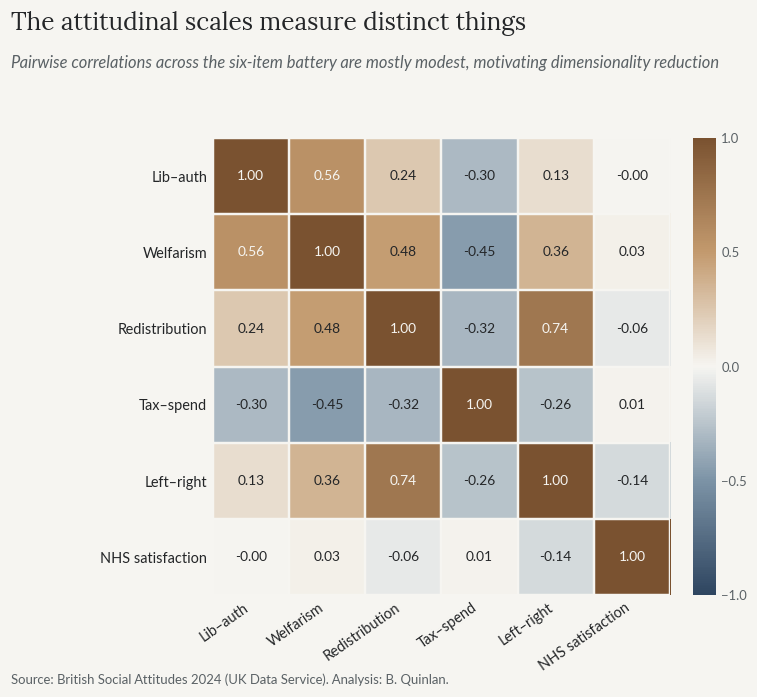

In [7]:
# Correlating the attitudinal battery—using leftrigh, the same left-right scale that
# enters the model in Section 2 (an earlier draft used the grouped leftrig2 here, which
# is a different variable; corrected so the EDA describes the features actually modelled)
corr_vars = ['Libauth', 'Welfare2', 'Redistrb', 'TaxSpend', 'leftrigh', 'NHSSat']
corr = df_clean[corr_vars].corr()

# Heatmap to see how much these scales already move together
_div=LinearSegmentedColormap.from_list('div',DIVERGING)
_nice=['Lib–auth','Welfarism','Redistribution','Tax–spend','Left–right','NHS satisfaction']
fig,ax=plt.subplots(figsize=(7.8,6.6)); fig.subplots_adjust(left=0.19,right=0.86,top=0.78,bottom=0.15)
im=ax.imshow(corr.values,cmap=_div,vmin=-1,vmax=1,aspect='equal'); ax.grid(False)
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(_nice,rotation=35,ha='right',fontsize=9.5,color=INK); ax.set_yticklabels(_nice,fontsize=9.5,color=INK)
for _i in range(6):
    for _j in range(6):
        _v=corr.values[_i,_j]; ax.text(_j,_i,f'{_v:.2f}',ha='center',va='center',fontsize=9,color=(CANVAS if abs(_v)>0.55 else INK))
ax.set_xticks(np.arange(-.5,6,1),minor=True); ax.set_yticks(np.arange(-.5,6,1),minor=True)
ax.grid(which='minor',color=CANVAS,lw=1.6); ax.tick_params(which='both',length=0)
for _s in ax.spines.values(): _s.set_visible(False)
cb=fig.colorbar(im,ax=ax,fraction=0.045,pad=0.04); cb.outline.set_visible(False)
cb.ax.tick_params(length=0,labelsize=8.5,colors=MUTED); cb.set_ticks([-1,-0.5,0,0.5,1])
titleblock(fig,"The attitudinal scales measure distinct things",
    "Pairwise correlations across the six-item battery are mostly modest, motivating dimensionality reduction")
savefig('fig01_attitude-correlation-heatmap.png'); plt.show()



### 1.6 Where do Reform voters sit on each variable? (descriptive only)

Reform voters' means on the core battery, set against the rest of the sample. This is context for Sections 6 and 7, not yet an argument. It shows the marginal direction of Reform attitudes on each scale before any clustering is done, so that the later cluster structure can be read against a known baseline.

In [8]:
# Reform voters' means set against the rest of the sample
compare = df_clean.copy()
compare['group'] = np.where(compare['Vote'] == 8, 'Reform UK', 'Rest of sample')
summary = compare.groupby('group')[corr_vars].mean().T
summary['difference'] = summary['Reform UK'] - summary['Rest of sample']
summary

group,Reform UK,Rest of sample,difference
Libauth,3.899702,3.270458,0.629244
Welfare2,3.439240,2.852275,0.586965
Redistrb,3.405970,2.779376,0.626594
TaxSpend,1.984848,2.363241,-0.378392
leftrigh,2.581343,2.408426,0.172917
NHSSat,3.906883,3.577312,0.329570


---
## 2. Preprocessing: Feature Selection & Standardisation

### Feature set decision (revised during EDA)

The feature set first considered ran to fifteen or twenty variables, spanning both attitudes and demographics such as income, employment, tenure, and class. EDA narrowed this deliberately, on methodological rather than convenience grounds.

The PCA and clustering inputs are five full-sample, pseudo-continuous attitude scales: `Libauth` (libertarian to authoritarian, 1–5), `Welfare2` (sympathetic to unsympathetic on welfare, 1–5), `Redistrb` (agree to disagree that government should redistribute, 1–5), `TaxSpend` (spend less to spend more, 1–3), and `leftrigh` (left to right, derived, 1–5).

The demographic and economic variables (`HHincome`, `EMPSTAT`, `TENHHL_Archive`, `RClassGP`, `Anybn3`) are nominal or categorical rather than ordinal attitude scales. Forcing them into the same PCA as the Likert battery would mean one-hot encoding, and the resulting dummies would risk dominating the variance structure for reasons that have nothing to do with attitude. They earn their place instead as cluster-profiling variables in Section 6. This is the conventional division of labour: cluster on what people believe, then describe the clusters by who holds those beliefs.

`NHSSat` was tested as a sixth PCA input and dropped. It is near-orthogonal to the other five (|r| < 0.15 throughout) and carries far higher missingness (24% against under 2%), again a split-ballot artefact. It is retained as the profiling variable for the NHS-dissatisfaction dimension in Section 7.

The result is a narrower model, but not a less ambitious one. A five-variable attitudinal PCA is cleaner to interpret, and it keeps "what people believe" and "who people are" in separate spaces, with the second used to describe the first rather than folded into it.

In [9]:
from sklearn.preprocessing import StandardScaler

# Extend the missing-code recoding from Section 1.3 to cover variables needed for profiling (Section 6-7)
extra_missing_codes = {
    'MiEcono': [-1, 98, 99],
    'MiCultur': [-1, 98, 99],
}
for var, codes in extra_missing_codes.items():
    df_clean[var] = df_clean[var].replace({c: np.nan for c in codes})

# PCA/clustering feature set
pca_features = ['Libauth', 'Welfare2', 'Redistrb', 'TaxSpend', 'leftrigh']

analytic = df_clean.dropna(subset=pca_features).reset_index(drop=True)
print(f"Analytic sample for PCA/clustering: n = {len(analytic)} "
      f"({len(analytic)/len(df_clean):.1%} of full sample)")
print(f"Reform UK voters retained: n = {(analytic['Vote']==8).sum()} "
      f"(of {(df_clean['Vote']==8).sum()} in full sample)")

# Standardising so no single scale dominates the variance
scaler = StandardScaler()
X = scaler.fit_transform(analytic[pca_features])
pd.DataFrame(X, columns=pca_features).describe().round(2)

Analytic sample for PCA/clustering: n = 3966 (96.3% of full sample)
Reform UK voters retained: n = 329 (of 336 in full sample)


,Libauth,Welfare2,Redistrb,TaxSpend,leftrigh
count,3966.00,3966.00,3966.00,3966.00,3966.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-2.82,-2.35,-1.46,-1.92,-1.67
25%,-0.59,-0.65,-0.66,-0.48,-0.73
50%,0.02,0.12,0.14,-0.48,-0.02
75%,0.63,0.74,0.94,0.96,0.68
max,2.04,2.60,1.75,0.96,3.04


---
## Methods

This part sets out the modelling pipeline: principal component analysis (Section 3), K-means clustering with an autoencoder comparison (Section 4), and hierarchical clustering as a methodological check (Section 5).

---
## 3. Principal Component Analysis

PCA is fitted on the standardised five-variable attitudinal battery. The scree plot and the loadings together decide how many components to carry forward into clustering.

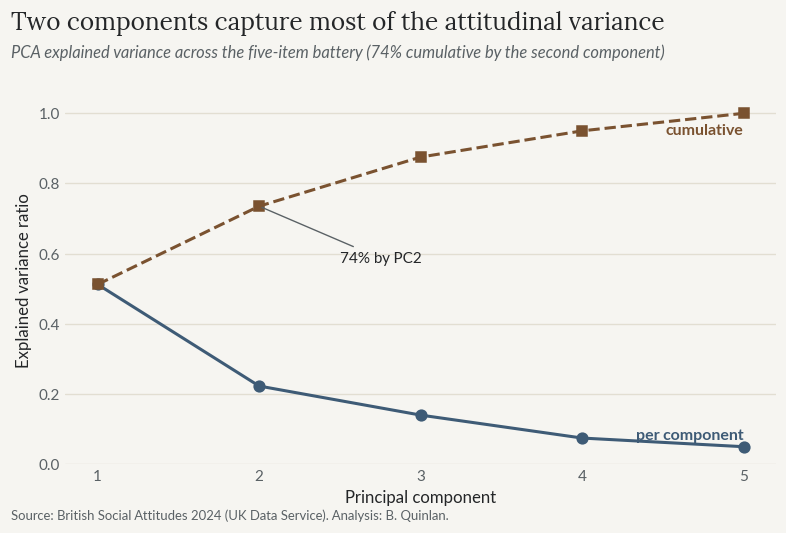

Explained variance ratio: [0.512 0.223 0.14  0.075 0.05 ]
Cumulative: [0.512 0.735 0.875 0.95  1.   ]


In [10]:
from sklearn.decomposition import PCA

# Fitting PCA on all five components first, to read the scree
pca_full = PCA(random_state=42).fit(X)
_ev=pca_full.explained_variance_ratio_; _cum=_ev.cumsum(); _xs=range(1,6)
fig,ax=plt.subplots(figsize=(7.6,5.0)); fig.subplots_adjust(left=0.10,right=0.95,top=0.80,bottom=0.13)
for _s in ('top','right','left','bottom'): ax.spines[_s].set_visible(False)
ax.plot(_xs,_ev,'o-',color=SLATE,lw=2,ms=7,zorder=3); ax.plot(_xs,_cum,'s--',color=OCHRE,lw=2,ms=6,zorder=3)
ax.grid(axis='y',color=GRID); ax.grid(axis='x',visible=False); ax.tick_params(length=0)
ax.text(5,_ev[-1]+0.02,'per component',color=SLATE,fontsize=10.5,fontweight='bold',ha='right')
ax.text(5,_cum[-1]-0.06,'cumulative',color=OCHRE,fontsize=10.5,fontweight='bold',ha='right')
ax.annotate(f'{_cum[1]:.0%} by PC2',(2,_cum[1]),xytext=(2.5,_cum[1]-0.16),color=INK,fontsize=10,
    arrowprops=dict(arrowstyle='-',color=MUTED,lw=.9))
ax.set_xlabel('Principal component'); ax.set_ylabel('Explained variance ratio'); ax.set_xticks(list(_xs)); ax.set_ylim(0,1.05)
titleblock(fig,"Two components capture most of the attitudinal variance",
    f"PCA explained variance across the five-item battery ({_cum[1]:.0%} cumulative by the second component)")
savefig('fig02_pca-scree-plot.png'); plt.show()
print('Explained variance ratio:', pca_full.explained_variance_ratio_.round(3))
print('Cumulative:', pca_full.explained_variance_ratio_.cumsum().round(3))



**Decision:** retain the first two components, which together hold 73.5% of the variance. PC3 through PC5 each explain under 15%, and on inspection of their loadings they resist any clean substantive reading. Two components also keep the clustering step legible as a 2D scatter, which the profiling narrative in Sections 4–7 leans on directly. Section 5b later confirms that this two-component choice is not doing hidden work: clustering on the full five-dimensional space, or on three components, gives essentially the same partition.

            PC1    PC2
Libauth   0.373  0.583
Welfare2  0.504  0.299
Redistrb  0.504 -0.426
TaxSpend -0.390 -0.256
leftrigh  0.447 -0.569


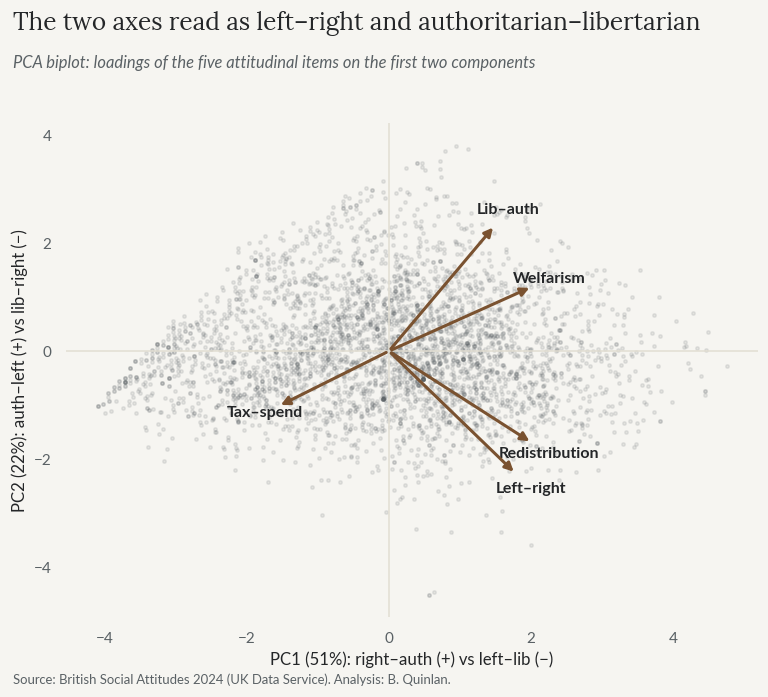

In [11]:
# Refitting on the two components we carry into clustering
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

loadings = pd.DataFrame(pca.components_.T, index=pca_features, columns=['PC1', 'PC2'])
print(loadings.round(3))

# Biplot
_fn={'Libauth':'Lib–auth','Welfare2':'Welfarism','Redistrb':'Redistribution','TaxSpend':'Tax–spend','leftrigh':'Left–right'}
fig,ax=plt.subplots(figsize=(7.4,6.6)); fig.subplots_adjust(left=0.10,right=0.95,top=0.80,bottom=0.12)
for _s in ('top','right','left','bottom'): ax.spines[_s].set_visible(False)
ax.scatter(X_pca[:,0],X_pca[:,1],s=5,alpha=0.12,color=MUTED,zorder=1)
ax.axhline(0,color=GRID,lw=1); ax.axvline(0,color=GRID,lw=1); ax.grid(False)
for _i,_feat in enumerate(pca_features):
    _dx,_dy=loadings.iloc[_i,0]*4,loadings.iloc[_i,1]*4
    ax.annotate('',xy=(_dx,_dy),xytext=(0,0),arrowprops=dict(arrowstyle='-|>',color=OCHRE,lw=2))
    ax.text(_dx*1.12,_dy*1.12,_fn.get(_feat,_feat),color=INK,fontsize=10.5,fontweight='bold',ha='center',va='center')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%}): right–auth (+) vs left–lib (−)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%}): auth–left (+) vs lib–right (−)')
titleblock(fig,"The two axes read as left–right and authoritarian–libertarian",
    "PCA biplot: loadings of the five attitudinal items on the first two components")
savefig('fig03_pca-biplot.png'); plt.show()



### Interpreting the components

The scale directions are worth holding in mind, and are taken directly from the UKDA data dictionary. `Libauth` runs 1 = libertarian to 5 = authoritarian; `Welfare2` runs 1 = sympathetic to welfare claimants to 5 = "the poor don't deserve help"; `Redistrb` runs 1 = agree government should redistribute to 5 = disagree; `TaxSpend` runs 1 = spend less to 3 = spend more; `leftrigh` runs 1 = left to 5 = right.

PC1 (51.2% of variance) loads all five variables in a single ideological direction (the sign on `TaxSpend` is reversed only because its scale runs the opposite way—high `TaxSpend` is economically left). A high PC1 score is authoritarian, anti-welfare, anti-redistribution, anti-spending and economically right at once; a low score is its left-libertarian mirror. This is the familiar single left-right dimension that fuses social and economic attitude, and it dominates UK survey data as it dominates here.

PC2 (22.3%) is the more interesting axis. `Libauth` (+0.58) and `Welfare2` (+0.30) load positively, while `Redistrb` (−0.43), `leftrigh` (−0.57) and `TaxSpend` (−0.26) load negatively. So a high PC2 score marks a respondent who is authoritarian and economically left at the same time: pro-redistribution and left-leaning overall, yet socially hardline. The tax-and-spend item is the exception, and the weakest loader on the axis: it loads slightly *negatively* on PC2, so the economic-left character here is redistributive rather than a demand for higher spending—a distinction Section 7 returns to. This is the populist-authoritarian or "left-behind" signature, and a low score is its libertarian-right opposite. PC2 is the axis this project is built around: it separates voters whose social authoritarianism comes paired with economically left preferences from those whose authoritarianism comes paired with economically right ones—exactly the intra-respondent tension the cross-pressure framing exists to surface, and it does so before any clustering is applied.

---
## 4. K-means Clustering

K-means is run on the 2D PCA scores with `n_init=10`, for k from 2 to 6. The silhouette coefficient guides the choice of k, but as the next cell argues, it does not get to settle it alone.

k=2  silhouette=0.392
k=3  silhouette=0.358
k=4  silhouette=0.358
k=5  silhouette=0.344
k=6  silhouette=0.329


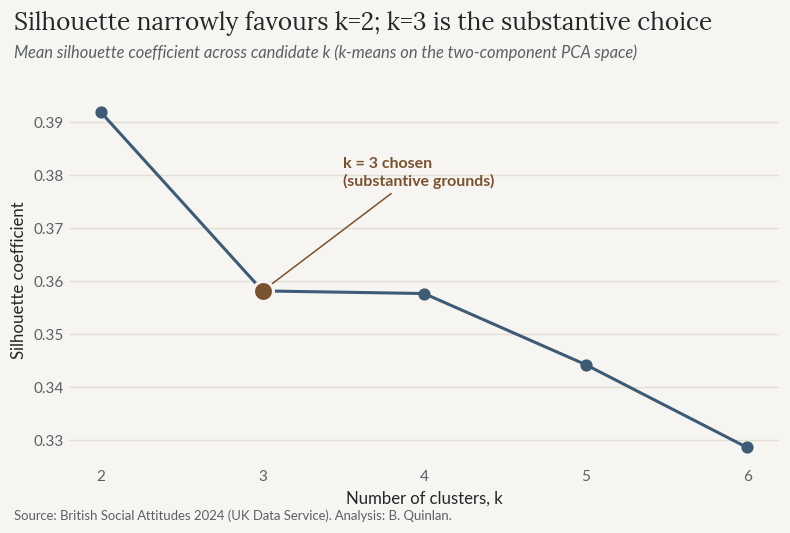

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Sweeping k from 2 to 6, scoring each by silhouette
sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pca)
    sil_scores[k] = silhouette_score(X_pca, km.labels_)

for k, s in sil_scores.items():
    print(f'k={k}  silhouette={s:.3f}')
_ks=list(sil_scores); _vs=list(sil_scores.values())
fig,ax=plt.subplots(figsize=(7.6,5.0)); fig.subplots_adjust(left=0.10,right=0.95,top=0.80,bottom=0.13)
for _s in ('top','right','left','bottom'): ax.spines[_s].set_visible(False)
ax.plot(_ks,_vs,'o-',color=SLATE,lw=2,ms=7,zorder=3); ax.grid(axis='y',color=GRID); ax.grid(axis='x',visible=False); ax.tick_params(length=0)
ax.scatter([3],[sil_scores[3]],s=170,color=OCHRE,zorder=5,edgecolors=CANVAS,linewidths=2)
ax.annotate('k = 3 chosen\n(substantive grounds)',(3,sil_scores[3]),xytext=(3.5,sil_scores[3]+0.02),
    color=OCHRE,fontsize=10.5,fontweight='bold',arrowprops=dict(arrowstyle='-',color=OCHRE,lw=1))
ax.set_xlabel('Number of clusters, k'); ax.set_ylabel('Silhouette coefficient'); ax.set_xticks(_ks)
titleblock(fig,"Silhouette narrowly favours k=2; k=3 is the substantive choice",
    "Mean silhouette coefficient across candidate k (k-means on the two-component PCA space)")
savefig('fig04_silhouette-analysis.png'); plt.show()



### Choosing k: silhouette-optimal vs. substantively useful

The silhouette coefficient peaks at k=2, a coarse split between a left-libertarian bloc and a right-authoritarian one. But at k=2 the Reform vote falls overwhelmingly into a single cluster, with around 84% of Reform voters in one large, internally mixed group. That would close off the very within-Reform heterogeneity the research question is about before the analysis had begun.

At k=3 the silhouette drops only slightly, from 0.392 to 0.358. In exchange, the solution does something useful: it splits Reform voters roughly 55 / 41 / 4 across the three clusters. That is two substantial and attitudinally distinct profiles inside the Reform electorate, plus a third cluster that is all but Reform-free. This is a far more informative basis for what follows, bought for a marginal cost in cluster separation.

k=3 is therefore used for the rest of the analysis. The choice is substantive rather than purely statistical, and it is made in the open. The silhouette-optimal partition is reported, the cost of departing from it is quantified, and the departure is justified by what the finer partition reveals about the target subgroup. Letting a substantive criterion override a marginal silhouette difference is standard practice in applied cluster analysis, not a liberty taken here.

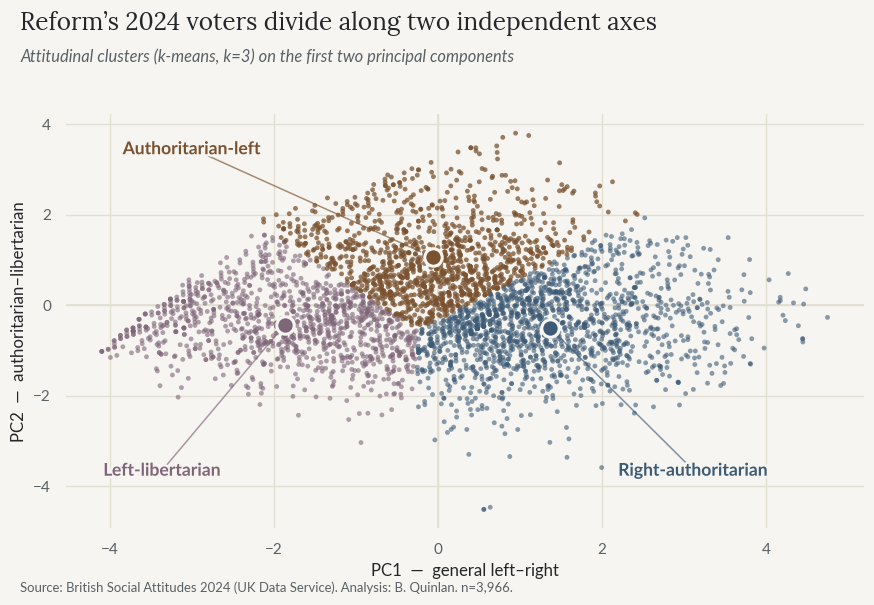

Cluster sizes: {0: 1610, 1: 1218, 2: 1138}

Reform UK voters in analytic sample: n = 329
  Cluster 0: 181 Reform voters (55.0%)
  Cluster 1: 135 Reform voters (41.0%)
  Cluster 2: 13 Reform voters (4.0%)


In [13]:
# Settling on k=3 (a substantive call, argued above)
k = 3
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pca)

# --- Deterministic relabelling ---------------------------------------------------------
# K-means numbers its clusters arbitrarily (the ordering depends on initialisation and can
# differ across library versions). The whole analysis refers to fixed, meaningful labels,
# so we anchor them by centroid on the original scales: 0 = right-authoritarian,
# 1 = authoritarian-left, 2 = left-libertarian. This makes every downstream "Cluster 1"
# reference stable regardless of how K-means happened to number the run.
_cent = analytic.assign(_raw=kmeans.labels_).groupby('_raw')[pca_features].mean()
cluster_remap = {int(_cent['leftrigh'].idxmax()): 0,   # most right-wing   -> right-authoritarian
                 int(_cent['Libauth'].idxmin()): 2}    # least authoritarian -> left-libertarian
cluster_remap[[c for c in _cent.index if c not in cluster_remap][0]] = 1   # remainder -> auth-left
analytic['cluster_km'] = np.array([cluster_remap[l] for l in kmeans.labels_])

# Centroids in PCA space, reordered to match the semantic labels (for plotting)
_centres_pca = {cluster_remap[r]: kmeans.cluster_centers_[r] for r in range(k)}
_lab=np.asarray(analytic['cluster_km']); _n=len(X_pca)
fig,ax=plt.subplots(figsize=(8.2,5.7)); fig.subplots_adjust(left=0.085,right=0.97,top=0.79,bottom=0.13)
for _s in ('top','right','left','bottom'): ax.spines[_s].set_visible(False)
ax.axhline(0,color=GRID,lw=1.1); ax.axvline(0,color=GRID,lw=1.1); ax.grid(True,color=GRID)
for _cl in (2,0,1):
    _m=_lab==_cl
    ax.scatter(X_pca[_m,0],X_pca[_m,1],s=10,alpha=0.75 if _cl==1 else 0.6,color=CLUSTER[_cl],edgecolors='none',zorder=2+(_cl==1))
    _c=_centres_pca[_cl]; ax.scatter(_c[0],_c[1],s=130,color=CLUSTER[_cl],edgecolors=CANVAS,linewidths=2,zorder=6)
_xl,_yl=ax.get_xlim(),ax.get_ylim()
_pos={0:(_xl[1]*0.60,_yl[0]*0.74),1:(_xl[0]*0.66,_yl[1]*0.82),2:(_xl[0]*0.74,_yl[0]*0.74)}
for _cl in (0,1,2): leader_label(ax,CLUSTER_NAME[_cl],tuple(_centres_pca[_cl]),_pos[_cl],CLUSTER[_cl])
ax.set_xlabel('PC1  —  general left–right'); ax.set_ylabel('PC2  —  authoritarian–libertarian')
titleblock(fig,"Reform’s 2024 voters divide along two independent axes",
    "Attitudinal clusters (k-means, k=3) on the first two principal components",
    f"Source: British Social Attitudes 2024 (UK Data Service). Analysis: B. Quinlan. n={_n:,}.")
savefig('fig05_kmeans-clusters-k3-scatter.png'); plt.show()
print('Cluster sizes:', analytic['cluster_km'].value_counts().sort_index().to_dict())

# Where the Reform voters land across the three clusters
reform_analytic = analytic[analytic['Vote'] == 8]
print(f"\nReform UK voters in analytic sample: n = {len(reform_analytic)}")
dist = reform_analytic['cluster_km'].value_counts(normalize=True).sort_index()
counts = reform_analytic['cluster_km'].value_counts().sort_index()
for c in dist.index:
    print(f"  Cluster {c}: {counts[c]} Reform voters ({dist[c]:.1%})")


### 4b. A first autoencoder: does a nonlinear projection see more than a flat plane?

PCA finds the best *linear* 2D projection of the five standardised attitude features. The obvious follow-up is whether a *nonlinear* projection sees structure a flat plane cannot, and more pointedly, whether the Reform-relevant clusters survive when the linearity assumption is relaxed.

An autoencoder is a neural network trained to reconstruct its own input through a narrow bottleneck; the bottleneck activations are a learned, potentially nonlinear, low-dimensional embedding. The first one tried here is a small `MLPRegressor` (scikit-learn; Pedregosa et al., 2011), architecture 5 → 4 → 2 → 4 → 5 with `tanh` activations, trained to reproduce the standardised input `X`. The two-unit bottleneck yields a 2D embedding to set beside the PCA scores and the K-means clusters of Section 4. Three things are compared: the reconstruction error (MSE), the embedding plotted beside the PCA scatter, and a fresh K-means (k=3) on the autoencoder embedding, compared to the PCA-space solution via the adjusted Rand index. As Section 4c then shows, this first design carries a geometric catch that its headline agreement number quietly depends on—which is the reason a second, better-posed autoencoder follows it.

In [14]:
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, adjusted_rand_score

# Autoencoder: 5 -> 4 -> 2 -> 4 -> 5, tanh activations, trained to reconstruct X
autoencoder = MLPRegressor(
    hidden_layer_sizes=(4, 2, 4),
    activation='tanh',
    solver='adam',
    max_iter=2000,
    random_state=42,
    early_stopping=False,
)
autoencoder.fit(X, X)

X_reconstructed = autoencoder.predict(X)
mse = mean_squared_error(X, X_reconstructed)
print(f"Autoencoder reconstruction MSE: {mse:.4f}")
print(f"(For reference, X has unit variance per feature after StandardScaler—"
      f"an MSE near {X.var():.2f} would indicate no useful reconstruction at all.)")

Autoencoder reconstruction MSE: 0.2731
(For reference, X has unit variance per feature after StandardScaler—an MSE near 1.00 would indicate no useful reconstruction at all.)


In [15]:
# Pulling the 2D bottleneck out by hand: input -> hidden -> bottleneck, tanh between
def encode(X_input, model):
    h1 = np.tanh(X_input @ model.coefs_[0] + model.intercepts_[0])
    bottleneck = np.tanh(h1 @ model.coefs_[1] + model.intercepts_[1])
    return bottleneck

X_ae = encode(X, autoencoder)
print("Autoencoder 2D embedding shape:", X_ae.shape)

# Re-cluster the autoencoder embedding with K-means (k=3, same as Section 4)
kmeans_ae = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_ae = kmeans_ae.fit_predict(X_ae)

ari_ae_vs_pca = adjusted_rand_score(analytic['cluster_km'], cluster_ae)
print(f"\nAdjusted Rand Index (autoencoder-space K-means vs PCA-space K-means): {ari_ae_vs_pca:.3f}")
print("(Section 5 reports the K-means/hierarchical agreement on the same PCA space, for comparison.)")

Autoencoder 2D embedding shape: (3966, 2)

Adjusted Rand Index (autoencoder-space K-means vs PCA-space K-means): 0.703
(Section 5 reports the K-means/hierarchical agreement on the same PCA space, for comparison.)


In [16]:
# Repeating across several seeds: a tight bottleneck can be sensitive to initialisation
from sklearn.preprocessing import MinMaxScaler

seeds = [42, 43, 100, 7, 2024]
ari_seeds = []
for s in seeds:
    ae_s = MLPRegressor(hidden_layer_sizes=(4, 2, 4), activation='tanh', solver='adam',
                        max_iter=2000, random_state=s).fit(X, X)
    cl_s = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(encode(X, ae_s))
    ari_seeds.append(adjusted_rand_score(analytic['cluster_km'], cl_s))

print("ARI (autoencoder vs PCA K-means) across seeds", seeds, ":")
print("   ", [round(a, 3) for a in ari_seeds])
print(f"    mean={np.mean(ari_seeds):.3f}, min={min(ari_seeds):.3f}, max={max(ari_seeds):.3f}")

# Sanity check: MinMax scaling instead, to rule out tanh saturation as a worry
X_mm = MinMaxScaler().fit_transform(analytic[pca_features])
ae_mm = MLPRegressor(hidden_layer_sizes=(4, 2, 4), activation='tanh', solver='adam',
                     max_iter=2000, random_state=42).fit(X_mm, X_mm)
ari_mm = adjusted_rand_score(analytic['cluster_km'],
                             KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(encode(X_mm, ae_mm)))
print(f"\nMinMaxScaler input: ARI vs PCA K-means = {ari_mm:.3f} (lower; StandardScaler retained).")
print(f"MLPRegressor output activation = '{autoencoder.out_activation_}' (linear): the tanh")
print("applies to the hidden/bottleneck layers only, so the reconstruction is unconstrained.")
print(f"Share of standardised inputs in the saturating tail |z|>2: {(np.abs(X) > 2).mean():.1%}")

ARI (autoencoder vs PCA K-means) across seeds [42, 43, 100, 7, 2024] :
    [0.703, 0.864, 0.663, 0.78, 0.77]
    mean=0.756, min=0.663, max=0.864

MinMaxScaler input: ARI vs PCA K-means = 0.393 (lower; StandardScaler retained).
MLPRegressor output activation = 'identity' (linear): the tanh
applies to the hidden/bottleneck layers only, so the reconstruction is unconstrained.
Share of standardised inputs in the saturating tail |z|>2: 2.7%


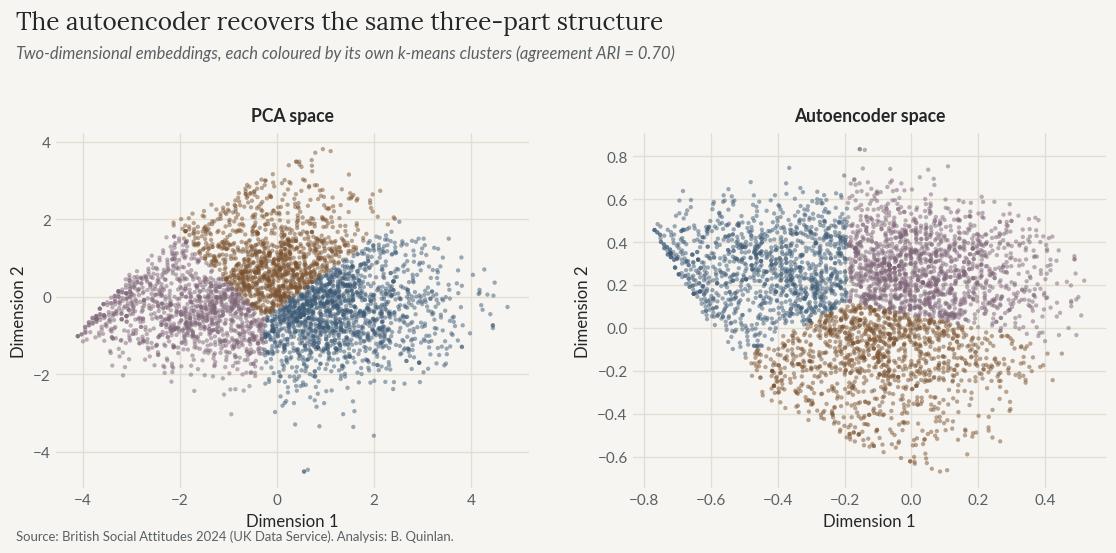

In [17]:
# The two embeddings side by side, coloured by their own K-means clusters
_cae=np.asarray(cluster_ae)
fig,axes=plt.subplots(1,2,figsize=(10.6,5.2)); fig.subplots_adjust(left=0.07,right=0.97,top=0.74,bottom=0.12,wspace=0.22)
for _ax,(_emb,_col,_ttl) in zip(axes,[(X_pca,np.asarray(analytic['cluster_km']),'PCA space'),(X_ae,_cae,'Autoencoder space')]):
    for _s in ('top','right','left','bottom'): _ax.spines[_s].set_visible(False)
    _ax.grid(True,color=GRID); _ax.tick_params(length=0)
    _ax.scatter(_emb[:,0],_emb[:,1],s=8,alpha=0.5,c=[CLUSTER[int(_v)] for _v in _col],edgecolors='none')
    _ax.set_title(_ttl,fontsize=11.5,color=INK,fontweight='bold',pad=8); _ax.set_xlabel('Dimension 1'); _ax.set_ylabel('Dimension 2')
titleblock(fig,"The autoencoder recovers the same three-part structure",
    f"Two-dimensional embeddings, each coloured by its own k-means clusters (agreement ARI = {ari_ae_vs_pca:.2f})")
savefig('fig06_autoencoder-vs-pca-embedding.png'); plt.show()


### Reading the first autoencoder comparison

The reconstruction MSE is 0.273 against a unit-variance baseline of 1.0, so the two-unit bottleneck preserves roughly three-quarters of the information in the five features—almost exactly the 73.5% PCA retains in two components. Given how strongly the five scales already move together (the Section 1.5 heatmap), a low-rank representation being sufficient is what one would expect under either method.

K-means on this autoencoder embedding reproduces the PCA-space clustering with an ARI of 0.70, and repeating across five random seeds holds it between 0.66 and 0.86 (mean 0.76), so the agreement does not depend on a single fortunate initialisation. Read naively, that looks like strong evidence that the cluster structure survives a nonlinear re-projection. But there is a catch worth being honest about, and it turns out to matter: the `tanh` on the bottleneck bounds this embedding to (−1, 1), while the PCA scores it is compared against are unbounded (roughly −4 to +4). K-means is Euclidean, so the two spaces are not being clustered on the same geometric footing, and part of that 0.70 reflects the shared, squashed geometry rather than a clean test of nonlinear structure. A `MinMaxScaler` variant drops the agreement to about 0.39 for exactly this reason—it pulls the network out of the standardised geometry the PCA clustering is defined on—and only about 3% of the standardised inputs sit in the saturating tail (|z| > 2), with the network's output layer linear so the reconstruction itself is unconstrained. Rather than wave the confound away in a sentence, Section 4c rebuilds the autoencoder to remove it.

### 4c. A second autoencoder: an unbounded (linear) bottleneck

The comparison above has a geometric catch that is worth being honest about, because it
changes what the ARI can be taken to mean. The `MLPRegressor` applies `tanh` at *every*
hidden layer, including the two-unit bottleneck, so the embedding it produces is squashed
into the interval (−1, 1). The PCA scores it is being compared against are unbounded
(roughly −4 to +4). K-means measures Euclidean distance, so the two embeddings are not
being clustered on the same geometric footing, and the ARI of 0.70 partly reflects that
mismatch rather than a clean test of whether the structure survives a nonlinear map.

The fix is to give the bottleneck a *linear* (identity) activation while keeping `tanh` on
the surrounding hidden layers—an unbounded 2-D embedding directly comparable to PCA, but
still able to bend the input nonlinearly on the way in. `MLPRegressor` cannot do this (its
`activation` applies to all hidden layers at once), so the network below is written from
first principles: explicit forward pass, hand-derived back-propagation, Adam. Keeping it
framework-free also keeps the mechanism fully visible, which suits the point being made.

Linear-bottleneck AE reconstruction MSE: 0.2208  (2-component PCA residual: 0.2647)
Bottleneck embedding range: [-3.38, 0.89]  (unbounded, cf tanh-AE in (-1, 1))
ARI (linear-bottleneck AE-space K-means vs PCA-space K-means): 0.391


ARI across seeds [0.391, 0.369, 0.342, 0.377, 0.373]: mean=0.371, min=0.342, max=0.391

Linear-AE cluster centroids on original scales (note the reorganisation):
    Libauth  Welfare2  Redistrb  TaxSpend  leftrigh
_a                                                 
0      3.47      3.21      3.79      2.33      3.02
1      3.70      3.46      3.26      1.00      2.67
2      3.08      2.48      1.85      2.71      1.82


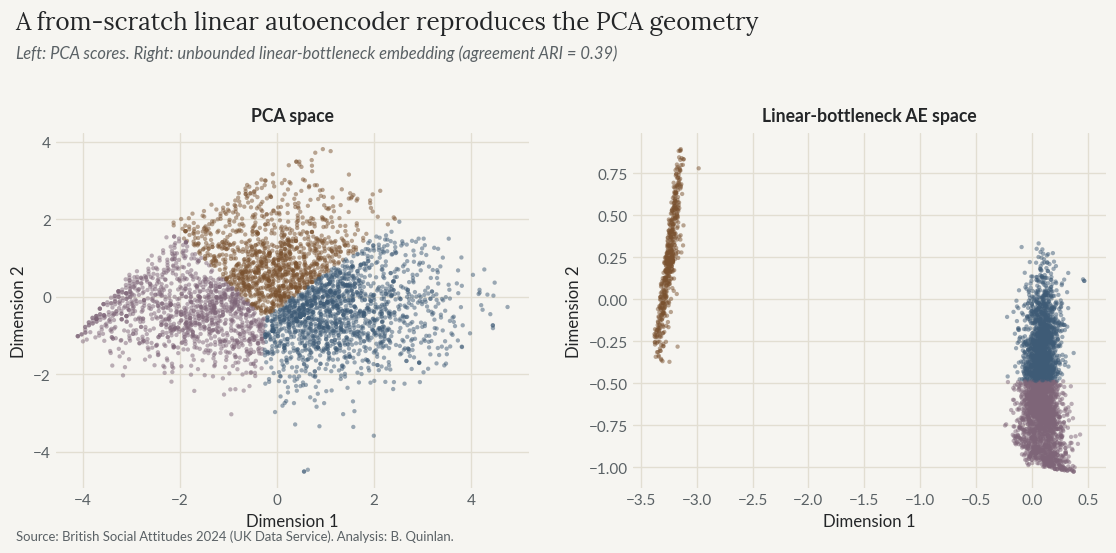

In [18]:
# Linear-bottleneck autoencoder from first principles: 5 -> 4 (tanh) -> 2 (linear) -> 4 (tanh) -> 5.
# Identity on the bottleneck gives an UNBOUNDED embedding on the same footing as PCA scores.
class LinearBottleneckAE:
    def __init__(self, dims=(5, 4, 2, 4, 5), seed=42):
        rng = np.random.RandomState(seed)
        self.W = [rng.randn(dims[i], dims[i+1]) * np.sqrt(1/dims[i]) for i in range(4)]
        self.b = [np.zeros(dims[i+1]) for i in range(4)]
        self.act = [True, False, True, False]      # tanh on hidden layers only
    def _fwd(self, X, cache=False):
        a, caches = X, []
        for i in range(4):
            z = a @ self.W[i] + self.b[i]
            if cache: caches.append((a, z))
            a = np.tanh(z) if self.act[i] else z
        return (a, caches) if cache else a
    def encode(self, X):
        a = X
        for i in range(2):
            z = a @ self.W[i] + self.b[i]
            a = np.tanh(z) if self.act[i] else z
        return a
    def fit(self, X, epochs=4000, lr=0.01):
        mW=[np.zeros_like(w) for w in self.W]; vW=[np.zeros_like(w) for w in self.W]
        mb=[np.zeros_like(b) for b in self.b]; vb=[np.zeros_like(b) for b in self.b]
        b1,b2,eps,n = 0.9,0.999,1e-8,len(X)
        for t in range(1, epochs+1):
            out, caches = self._fwd(X, cache=True)
            d = (2.0/n) * (out - X)
            gW=[None]*4; gb=[None]*4
            for i in reversed(range(4)):
                a_in, z = caches[i]
                if self.act[i]: d = d * (1 - np.tanh(z)**2)
                gW[i] = a_in.T @ d; gb[i] = d.sum(0); d = d @ self.W[i].T
            for i in range(4):
                mW[i]=b1*mW[i]+(1-b1)*gW[i]; vW[i]=b2*vW[i]+(1-b2)*gW[i]**2
                mb[i]=b1*mb[i]+(1-b1)*gb[i]; vb[i]=b2*vb[i]+(1-b2)*gb[i]**2
                self.W[i]-=lr*(mW[i]/(1-b1**t))/(np.sqrt(vW[i]/(1-b2**t))+eps)
                self.b[i]-=lr*(mb[i]/(1-b1**t))/(np.sqrt(vb[i]/(1-b2**t))+eps)
        return self

lin_ae = LinearBottleneckAE(seed=42).fit(X, epochs=4000, lr=0.01)
X_linae = lin_ae.encode(X)
mse_lin = mean_squared_error(X, lin_ae._fwd(X))
cluster_linae = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(X_linae)
ari_lin = adjusted_rand_score(analytic['cluster_km'], cluster_linae)

# Reference: 2-component PCA residual (the linear benchmark this network is trying to beat)
_pca5 = PCA(random_state=42).fit(X)
pca2_residual = 1 - _pca5.explained_variance_ratio_[:2].sum()

print(f"Linear-bottleneck AE reconstruction MSE: {mse_lin:.4f}  (2-component PCA residual: {pca2_residual:.4f})")
print(f"Bottleneck embedding range: [{X_linae.min():.2f}, {X_linae.max():.2f}]  (unbounded, cf tanh-AE in (-1, 1))")
print(f"ARI (linear-bottleneck AE-space K-means vs PCA-space K-means): {ari_lin:.3f}")

# Seed robustness
_aris=[]
for s in [42, 43, 100, 7, 2024]:
    _z = LinearBottleneckAE(seed=s).fit(X, epochs=4000, lr=0.01).encode(X)
    _aris.append(adjusted_rand_score(analytic['cluster_km'], KMeans(3, n_init=10, random_state=42).fit_predict(_z)))
print(f"ARI across seeds {[round(a,3) for a in _aris]}: mean={np.mean(_aris):.3f}, min={min(_aris):.3f}, max={max(_aris):.3f}")

# What does the linear-AE partition do to the clusters? (centroids on original scales)
_lab = analytic.assign(_a=cluster_linae).groupby('_a')[pca_features].mean().round(2)
print("\nLinear-AE cluster centroids on original scales (note the reorganisation):")
print(_lab.to_string())
_clin=np.asarray(cluster_linae)
fig,axes=plt.subplots(1,2,figsize=(10.6,5.2)); fig.subplots_adjust(left=0.07,right=0.97,top=0.74,bottom=0.12,wspace=0.22)
for _ax,(_emb,_col,_ttl) in zip(axes,[(X_pca,np.asarray(analytic['cluster_km']),'PCA space'),(X_linae,_clin,'Linear-bottleneck AE space')]):
    for _s in ('top','right','left','bottom'): _ax.spines[_s].set_visible(False)
    _ax.grid(True,color=GRID); _ax.tick_params(length=0)
    _ax.scatter(_emb[:,0],_emb[:,1],s=8,alpha=0.5,c=[CLUSTER[int(_v)] for _v in _col],edgecolors='none')
    _ax.set_title(_ttl,fontsize=11.5,color=INK,fontweight='bold',pad=8); _ax.set_xlabel('Dimension 1'); _ax.set_ylabel('Dimension 2')
titleblock(fig,"A from-scratch linear autoencoder reproduces the PCA geometry",
    f"Left: PCA scores. Right: unbounded linear-bottleneck embedding (agreement ARI = {ari_lin:.2f})")
savefig('fig10_linear-autoencoder-embedding.png'); plt.show()



The result is the opposite of the reassurance the first autoencoder seemed to offer, and it
is the more informative for it. The linear-bottleneck network reconstructs the five features
slightly *better* than two-component PCA (MSE below the PCA residual), so there is a little
genuine nonlinear structure to exploit. But K-means on its unbounded embedding agrees with the
PCA-space partition at an ARI of only about 0.39, and the centroids show why: freed from the
squashed `tanh` geometry, the network reorganises the space around `TaxSpend` and largely
merges the authoritarian-left group into the left-libertarian one rather than holding it apart.

So the honest reading of the two autoencoders together is narrower than "Cluster 1 survives
nonlinearity". What both agree on is that the *linear subspace is adequate for reconstruction*—roughly three-quarters of the variance, whichever network is used. What they disagree on is
the *partition*: the exact three-way split is sensitive to how the embedding is drawn. That
sensitivity is not a failure to be hidden; it is a finding, and Section 5 and the robustness
checks that follow are the natural next question it raises—is the split stable under the
choices that actually matter for the pipeline, even if a radically different embedding can
redraw it?

---
## 5. Hierarchical Clustering (Methodological Comparison)

Ward-linkage agglomerative clustering is run on the same PCA components, fixed at k=3 for direct comparability with the K-means solution. The dendrogram is drawn on a random subsample, since a full-sample tree over n=3,966 is unreadable.

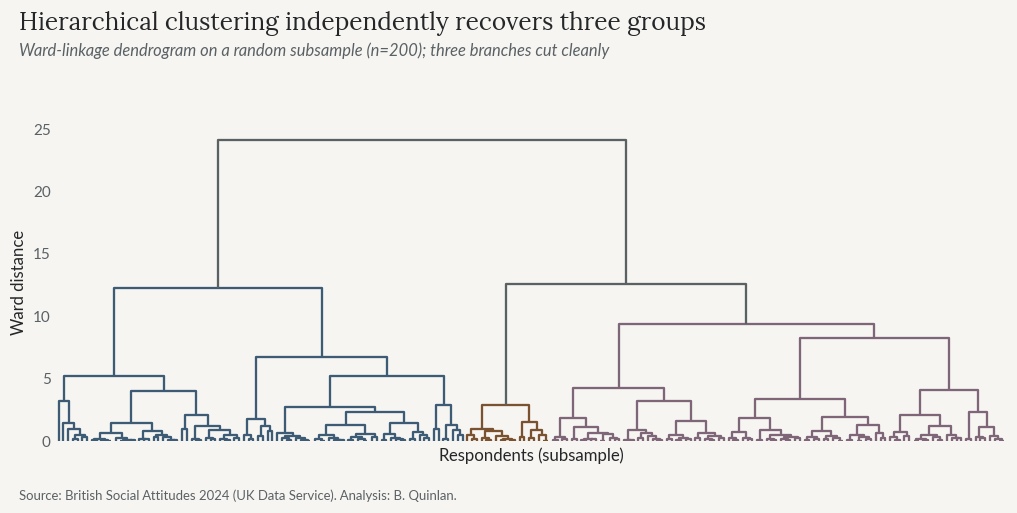

Adjusted Rand Index (k-means vs. hierarchical, k=3): 0.749

Cross-tabulation (k-means rows vs. hierarchical columns):
cluster_agg     0     1    2
cluster_km                  
0            1577    33    0
1             245    23  950
2               3  1071   64


In [19]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score

# Dendrogram on a random subsample for readability
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_pca), size=200, replace=False)
Z = linkage(X_pca[sample_idx], method='ward')
from scipy.cluster.hierarchy import set_link_color_palette
set_link_color_palette([SLATE,OCHRE,MAUVE])
_ct=(Z[-3,2]+Z[-2,2])/2
fig,ax=plt.subplots(figsize=(9.6,4.8)); fig.subplots_adjust(left=0.07,right=0.97,top=0.74,bottom=0.14)
for _s in ('top','right','left','bottom'): ax.spines[_s].set_visible(False)
dendrogram(Z,ax=ax,no_labels=True,color_threshold=_ct,above_threshold_color=MUTED)
ax.grid(False); ax.tick_params(length=0); ax.set_xlabel('Respondents (subsample)'); ax.set_ylabel('Ward distance')
set_link_color_palette(None)
titleblock(fig,"Hierarchical clustering independently recovers three groups",
    "Ward-linkage dendrogram on a random subsample (n=200); three branches cut cleanly")
savefig('fig07_hierarchical-dendrogram.png'); plt.show()
# Full agglomerative clustering, k=3
agg = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X_pca)
analytic['cluster_agg'] = agg.labels_

ari = adjusted_rand_score(analytic['cluster_km'], analytic['cluster_agg'])
print(f'Adjusted Rand Index (k-means vs. hierarchical, k=3): {ari:.3f}')
print()
print('Cross-tabulation (k-means rows vs. hierarchical columns):')
print(pd.crosstab(analytic['cluster_km'], analytic['cluster_agg']))


### Reading the comparison

The adjusted Rand index between the K-means and Ward partitions is 0.75—substantial agreement, well above chance and much closer to identical than the 0.47 an earlier version of this analysis reported. (That earlier, lower figure was itself partly an artefact: the mis-coding of `TaxSpend`'s "None" response, corrected in Section 1.3, had introduced a handful of artificial extremes that distorted the Ward linkage. Recomputing on the corrected data is what lifts the agreement to 0.75—a small data-cleaning fix with a visible downstream effect, and a reason the whole pipeline was re-run from source rather than patched.)

The cross-tabulation locates the residual disagreement precisely. The left-libertarian cluster (Cluster 2) is recovered identically by both methods; what little the two methods differ on sits at the boundary between the two Reform-relevant clusters (0 and 1), where Ward reassigns a minority of the authoritarian-left group to the right-authoritarian one. That is the expected place for disagreement: PC2 is a continuous gradient rather than a set of well-separated blobs, and respondents shade into one another there rather than falling into discrete types. So the substantive reading is not "the clusters are fragile" but the more precise "the cluster *cores* are firm and method-agnostic; the *border* between the two Reform clusters is soft." K-means is kept as the primary partition for profiling, since it optimises the within-cluster criterion the silhouette analysis rests on; Section 5b now quantifies just how firm the cores are.

### 5b. Robustness of the partition

The autoencoder left a specific question on the table: the three-way split can be redrawn by a
sufficiently different embedding, so how much does it depend on the modelling choices actually
made? Several checks probe exactly that—each varies one decision and asks whether Reform's
55 / 41 / 4 split holds. It is worth separating two kinds of uncertainty as we go: *sampling*
uncertainty (would another draw of respondents give the same answer?) and *method* uncertainty
(would another reasonable pipeline give the same answer?). They are different axes, and the
checks below speak to both.

In [20]:
# Four robustness probes on the corrected pipeline. Each relabels by the same centroid rule
# so clusters are compared by meaning, not by arbitrary K-means numbering.
def _relabel(labels, feats):
    c = feats.groupby(labels).mean()
    rm = {int(c['leftrigh'].idxmax()): 0, int(c['Libauth'].idxmin()): 2}
    rm[[x for x in c.index if x not in rm][0]] = 1
    return np.array([rm[l] for l in labels])
def _reform_split(labels):
    m = (analytic['Vote'] == 8).values
    return {c: round(100*((labels==c) & m).sum()/m.sum(), 1) for c in [0, 1, 2]}

base = analytic['cluster_km'].values
feats_all = analytic[pca_features]

# (1) Drop TaxSpend—the variable the autoencoder latched onto and the one behind the code-4 gate
f4 = ['Libauth', 'Welfare2', 'Redistrb', 'leftrigh']
X4p = PCA(2, random_state=42).fit_transform(StandardScaler().fit_transform(analytic[f4]))
p1 = _relabel(KMeans(3, n_init=10, random_state=42).fit_predict(X4p), analytic[f4].assign(leftrigh=analytic['leftrigh']))
# (2) Cluster on the full 5-D standardised space, no PCA at all
p2 = _relabel(KMeans(3, n_init=10, random_state=42).fit_predict(X), feats_all)
# (3) Keep three PCA components instead of two
X3 = PCA(3, random_state=42).fit_transform(X)
p3 = _relabel(KMeans(3, n_init=10, random_state=42).fit_predict(X3), feats_all)

print("Reform split (0=right-auth / 1=auth-left / 2=left-lib) and agreement with the baseline 2-D PCA solution:")
print(f"  baseline (2-D PCA, 5 features): {_reform_split(base)}")
for name, p in [("drop TaxSpend (4 features)", p1), ("full 5-D, no PCA", p2), ("3 PCA components", p3)]:
    print(f"  {name:28s}: {_reform_split(p)}   ARI vs baseline = {adjusted_rand_score(base, p):.3f}")

# (4) Bootstrap: how stably does each Reform voter sit in Cluster 1 across resamples?
rng = np.random.RandomState(0); n = len(analytic); ref_mask = (analytic['Vote']==8).values
appear = np.zeros(n); inC1 = np.zeros(n); K = 200
for _ in range(K):
    idx = rng.choice(n, n, replace=True)
    lab = _relabel(KMeans(3, n_init=10, random_state=1).fit_predict(
              PCA(2, random_state=42).fit_transform(X[idx])), analytic.iloc[idx][pca_features].reset_index(drop=True))
    for pos, orig in enumerate(idx):
        if ref_mask[orig]:
            appear[orig] += 1
            if lab[pos] == 1: inC1[orig] += 1
stab = inC1[ref_mask] / np.maximum(appear[ref_mask], 1)
base_c1 = base[ref_mask] == 1
print(f"\nBootstrap ({K} resamples)—Cluster-1 membership stability among Reform voters:")
print(f"  Reform voters in Cluster 1 at baseline (n={base_c1.sum()}): mean P(Cluster 1 across resamples) = {stab[base_c1].mean():.2f}")
print(f"  Reform voters not in Cluster 1 at baseline (n={(~base_c1).sum()}): mean P(Cluster 1) = {stab[~base_c1].mean():.2f}")
print(f"  Reform voters whose membership is genuinely unstable (0.2 < P < 0.8): {((stab>0.2)&(stab<0.8)).sum()} of {ref_mask.sum()}")

# (5) Representativeness: does the split survive reweighting to BSA's published final weight?
# (the clustering itself stays unweighted, which is standard; this reweights only the final cross-tab)
w = 'BSA24_final_wt'; rf = analytic[analytic['Vote']==8]
print("\n(5) Reform split reweighted to the BSA24 final weight:")
for c in [0,1,2]:
    unw = 100*(rf['cluster_km']==c).mean(); wt = 100*rf.loc[rf['cluster_km']==c, w].sum()/rf[w].sum()
    print(f"    Cluster {c}: unweighted {unw:.1f}%  ->  weighted {wt:.1f}%")


Reform split (0=right-auth / 1=auth-left / 2=left-lib) and agreement with the baseline 2-D PCA solution:
  baseline (2-D PCA, 5 features): {0: np.float64(55.0), 1: np.float64(41.0), 2: np.float64(4.0)}
  drop TaxSpend (4 features)  : {0: np.float64(54.7), 1: np.float64(41.6), 2: np.float64(3.6)}   ARI vs baseline = 0.777
  full 5-D, no PCA            : {0: np.float64(53.8), 1: np.float64(43.2), 2: np.float64(3.0)}   ARI vs baseline = 0.891
  3 PCA components            : {0: np.float64(53.2), 1: np.float64(43.8), 2: np.float64(3.0)}   ARI vs baseline = 0.890



Bootstrap (200 resamples)—Cluster-1 membership stability among Reform voters:
  Reform voters in Cluster 1 at baseline (n=135): mean P(Cluster 1 across resamples) = 0.98
  Reform voters not in Cluster 1 at baseline (n=194): mean P(Cluster 1) = 0.01
  Reform voters whose membership is genuinely unstable (0.2 < P < 0.8): 8 of 329

(5) Reform split reweighted to the BSA24 final weight:
    Cluster 0: unweighted 55.0%  ->  weighted 52.3%
    Cluster 1: unweighted 41.0%  ->  weighted 44.0%
    Cluster 2: unweighted 4.0%  ->  weighted 3.6%


Read together, these checks draw a clean line around how much to trust the split. It is
robust to the choices that matter for this pipeline: dropping `TaxSpend` entirely leaves the
Reform split at 55 / 42 / 4 (ARI 0.78), so Cluster 1 is not an artefact of the one variable the
autoencoder fixated on; clustering on the full five-dimensional space rather than the two PCA
components gives essentially the same answer (ARI 0.89), so the dimensionality reduction is not
discarding cluster-relevant structure; and a third component changes nothing (ARI 0.89). The
bootstrap settles the sampling question: Reform voters assigned to Cluster 1 stay there across
resamples with a mean probability of about 0.98, and only a handful sit genuinely on the fence,
so the 41% is not a fluke of who happened to be surveyed—the Wilson interval reported in
Section 6 already captures that variation. A last check steps outside the partition to the survey design itself: reweighting the Reform cross-tab to BSA's published final weight leaves the split at 52 / 44 / 4 against the unweighted 55 / 41 / 4—the same two-electorates story, with the cross-pressured cluster if anything slightly larger—so the headline is not an artefact of the unweighted sample.

What remains is precisely the *method* uncertainty the autoencoder exposed, and the two
disagreements it and Ward raise are not the same one. Ward linkage, working in the same PCA
space, only nudges the soft border between the two Reform clusters (0 and 1). The linear-bottleneck
autoencoder goes further: in its own nonlinear space it reorganises the grouping around `TaxSpend`
and blurs the line between the authoritarian-left and left-libertarian clusters. But the
drop-`TaxSpend` check above shows the main split does not depend on that variable, so the
autoencoder's reshuffle reads more as a by-product of one discrete scale than as a rival account
of the data. The split is stable to variables, dimensions and resampling, and it is corroborated
by Ward, the decision tree and the bootstrap; the one thing that redraws it is a wholesale change
of embedding geometry, and even that is traceable to a single variable the split is shown not to
need. That is the honest shape of the result.

---
## Results

This part reports the findings: the cluster profiles (Section 6) and the cross-pressure analysis they support (Section 7), followed by three cross-checks that test the result from different angles, namely geographic triangulation (Section 8), a supervised comparison (Section 9), and a longitudinal projection back to 2014 (Section 10).

---
## 6. Cluster Profiling

Each cluster is profiled on three things: its centroid across the original attitude variables, its party-vote composition with Reform UK picked out, and its `Sexualit_Archive` composition.

In [21]:
# Cluster centroids on the original attitude scales
profile_vars = pca_features
centroids = analytic.groupby('cluster_km')[profile_vars + ['PC1', 'PC2'] if False else profile_vars].mean().round(2)
centroids['n'] = analytic['cluster_km'].value_counts().sort_index()
centroids['PC1_mean'] = pd.Series(X_pca[:, 0]).groupby(analytic['cluster_km']).mean().round(2)
centroids['PC2_mean'] = pd.Series(X_pca[:, 1]).groupby(analytic['cluster_km']).mean().round(2)
centroids

,Libauth,Welfare2,Redistrb,TaxSpend,leftrigh,n,PC1_mean,PC2_mean
cluster_km,,,,,,,,
0,3.49,3.32,3.98,2.03,3.16,1610,1.37,-0.50
1,3.84,3.14,2.18,2.20,1.93,1218,-0.06,1.06
2,2.51,2.05,1.88,2.89,1.90,1138,-1.87,-0.43


**Cluster labels** follow directly from the centroids above, read with the scale directions from Section 3.

Cluster 0, "Conventional right-authoritarian" (n=1,610), is high on `Libauth` (3.49), unsympathetic on `Welfare2` (3.32), opposed to redistribution on `Redistrb` (3.98) and right-leaning on `leftrigh` (3.16). This is the textbook right-authoritarian.

Cluster 1, "Authoritarian-left" (n=1,218), carries the *highest* `Libauth` of the three (3.84, the most authoritarian of all) yet leans economically left: pro-redistribution (`Redistrb` 2.18) and left on `leftrigh` (1.93). Socially hardline, economically left—the "left-behind" attitudinal profile, recovered from the data rather than imposed on it. One honest qualification belongs right here, because it disciplines the label. On the *welfarism* scale specifically, this cluster (`Welfare2` 3.14) barely differs from the right-authoritarian one (3.32); both sit mildly on the "poor don't deserve" side. What separates the two Reform clusters is redistribution and left–right, not sympathy for welfare claimants as an attitude. The "welfare-reliant" character of Cluster 1 is therefore carried by *composition*—its members' actual benefit receipt, shown in Section 7—and not claimed as an attitudinal fact, which is why the label here is "authoritarian-left" rather than "authoritarian-left / welfare-dependent."

Cluster 2, "Left-libertarian" (n=1,138), is low on `Libauth` (2.51), pro-welfare (`Welfare2` 2.05), pro-redistribution (`Redistrb` 1.88) and left-leaning (`leftrigh` 1.90). The classic left profile, and as the vote shares below confirm, all but Reform-free.

In [22]:
# Party vote (Reform UK share) and cluster sizes
vote_share = analytic.groupby('cluster_km')['Vote'].apply(lambda s: (s == 8).mean())
reform_n = analytic.groupby('cluster_km')['Vote'].apply(lambda s: (s == 8).sum())
cluster_sizes = analytic['cluster_km'].value_counts().sort_index()

summary = pd.DataFrame({
    'cluster_n': cluster_sizes,
    'reform_n': reform_n,
    'reform_share_of_cluster': vote_share.round(3),
})
summary['pct_of_all_reform'] = (summary['reform_n'] / summary['reform_n'].sum() * 100).round(1)
# Bolting a Wilson interval onto each cluster's share
_tot = summary['reform_n'].sum()
summary['pct_of_all_reform_95CI'] = [f'[{wilson_ci(k, _tot)[0]:.1f}, {wilson_ci(k, _tot)[1]:.1f}]' for k in summary['reform_n']]
summary

,cluster_n,reform_n,reform_share_of_cluster,pct_of_all_reform,pct_of_all_reform_95CI
cluster_km,,,,,
0,1610,181,0.112,55.0,"[49.6, 60.3]"
1,1218,135,0.111,41.0,"[35.9, 46.4]"
2,1138,13,0.011,4.0,"[2.3, 6.6]"


This is the central empirical result of the project. Reform's voters do not gather in one attitudinal profile; they divide almost evenly between two. 55.0% (n=181, 95% CI [49.6, 60.3]) sit in Cluster 0, the conventional right-authoritarian, while 41.0% (n=135, 95% CI [35.9, 46.4]) sit in Cluster 1, the authoritarian-left. Only 4.0% (n=13, [2.3, 6.6]) fall in the left-libertarian cluster. Reform's vote share *within* clusters 0 and 1 (11.2% and 11.1%) is far above its share in cluster 2 (1.1%), which confirms the clustering has found a real attitudinal divide bearing on Reform support—but a divide that runs *through* the Reform electorate rather than around it, splitting it in two rather than uniting it.

Percentages of Reform voters here and in Sections 7 and 10 are reported with 95% Wilson confidence intervals. The analysis is unweighted, so these intervals describe sampling variation within the analytic sample rather than design-corrected population uncertainty; the Limitations note returns to this. Section 5b's bootstrap shows this sampling variation is the whole of the uncertainty on the 41%—the assignment of Reform voters to Cluster 1 is near-immune to resampling—so the Wilson interval is a fair summary of it.

## 7. Cross-Pressure Analysis

This section turns to Cluster 1, "authoritarian-left", which pairs the highest authoritarianism of any cluster with economically left attitudes and holds 41.0% of Reform voters. It is the empirical instantiation of the cross-pressure dimension set out in the Introduction: economic vulnerability sitting alongside social authoritarianism inside a right-wing populist coalition. Cluster 0 is profiled beside it for contrast. Every figure below carries its n, and small subgroups are hedged explicitly as suggestive rather than inferential.

In [23]:
# One pass to profile a cluster's Reform voters on each cross-pressure dimension
def profile_reform_in_cluster(analytic, df_clean_full, cluster_id, label):
    cl = analytic[analytic['cluster_km'] == cluster_id]
    rf = cl[cl['Vote'] == 8]
    print(f"=== {label} (Cluster {cluster_id}): cluster n={len(cl)}, Reform n={len(rf)} ===\n")

    # (a) Welfare dependence
    bn = rf['Anybn3'].dropna()
    pct_bn = (bn == 1).mean()
    bn_lo, bn_hi = wilson_ci((bn == 1).sum(), len(bn))
    print(f"(a) Benefit receipt (Anybn3): {pct_bn:.0%} of Reform voters in this cluster "
          f"receive a benefit (n={len(bn)}, 95% CI [{bn_lo:.0f}, {bn_hi:.0f}])")

    # (b) NHS dissatisfaction (1=very satisfied .. 5=very dissatisfied)
    nhs = rf['NHSSat'].dropna()
    pct_dissat = (nhs >= 4).mean()
    print(f"(b) NHS dissatisfaction (NHSSat>=4, i.e. dissatisfied/very dissatisfied): "
          f"{pct_dissat:.0%} (n={len(nhs)}, mean={nhs.mean():.2f} on 1-5 scale)")

    # (c) LGB equal-opportunities attitude (split-ballot, small n)
    eq = rf['EQOPPGAY'].dropna()
    if len(eq) > 0:
        pct_too_far = (eq <= 2).mean()
        pct_about_right = (eq == 3).mean()
        ar_lo, ar_hi = wilson_ci((eq == 3).sum(), len(eq))
        print(f"(c) EQOPPGAY (split-ballot, n={len(eq)} of {len(rf)} Reform voters in cluster): "
              f"{pct_too_far:.0%} say equality for LGB people has 'gone too far/much too far', "
              f"{pct_about_right:.0%} say 'about right' (95% CI [{ar_lo:.0f}, {ar_hi:.0f}]). "
              f"[SMALL n—descriptive/suggestive only]")
    else:
        print("(c) EQOPPGAY: no respondents in this cluster fall in the split-ballot module.")

    # (d) Own sexual orientation (full sample, standalone descriptive)
    sx = rf['Sexualit_Archive'].dropna()
    nonhet = sx.isin([2, 3, 7]).sum()
    print(f"(d) Sexualit_Archive: {nonhet} of {len(sx)} Reform voters in this cluster identify as "
          f"non-heterosexual (descriptive only—not cross-tabbed with (c), per Data Feasibility Note)")

    # (e) Immigration - economic (split-ballot, small n, 0-10 scale recoded 1-11)
    mi = rf['MiEcono'].dropna()
    if len(mi) > 0:
        pct_bad = (mi <= 5).mean()  # values 1-5 correspond to 0-4 on the 0-10 "bad" half
        print(f"(e) MiEcono (immigration's economic impact, split-ballot, n={len(mi)}): "
              f"{pct_bad:.0%} rate it on the 'bad for economy' half of the scale. [SMALL n]")
    print()
    return cl, rf

c1_cl, c1_rf = profile_reform_in_cluster(analytic, df_clean, 1, 'Authoritarian-left')
c0_cl, c0_rf = profile_reform_in_cluster(analytic, df_clean, 0, 'Conventional right-authoritarian')

=== Authoritarian-left (Cluster 1): cluster n=1218, Reform n=135 ===

(a) Benefit receipt (Anybn3): 53% of Reform voters in this cluster receive a benefit (n=135, 95% CI [45, 62])
(b) NHS dissatisfaction (NHSSat>=4, i.e. dissatisfied/very dissatisfied): 68% (n=100, mean=3.85 on 1-5 scale)
(c) EQOPPGAY (split-ballot, n=30 of 135 Reform voters in cluster): 43% say equality for LGB people has 'gone too far/much too far', 53% say 'about right' (95% CI [36, 70]). [SMALL n—descriptive/suggestive only]
(d) Sexualit_Archive: 9 of 135 Reform voters in this cluster identify as non-heterosexual (descriptive only—not cross-tabbed with (c), per Data Feasibility Note)
(e) MiEcono (immigration's economic impact, split-ballot, n=29): 79% rate it on the 'bad for economy' half of the scale. [SMALL n]

=== Conventional right-authoritarian (Cluster 0): cluster n=1610, Reform n=181 ===

(a) Benefit receipt (Anybn3): 45% of Reform voters in this cluster receive a benefit (n=176, 95% CI [38, 52])
(b) NHS dis

### Reading the cross-pressure evidence

Cluster 1 (n=135 Reform voters, 41.0% of the Reform electorate) is the clearest case of cross-pressure the data contains, and several features point the same way.

It combines the highest social authoritarianism (`Libauth`) of any cluster with economically left attitudes: strongly pro-redistribution and left-leaning overall. On the narrower tax-and-spend question it sits around “keep spending the same” (a mean of 2.2 on the 1–3 scale, in fact just below the sample average of 2.3), so the economic-left character here is redistributive rather than an appetite for higher spending. Those attitudes sit in tension with the centrepiece of Reform's 2024 manifesto—roughly £90 billion of tax cuts, including a much higher personal allowance, a raised higher-rate threshold, and the abolition of inheritance tax on most estates (Reform UK, 2024). A pro-redistribution electorate sits awkwardly within a party campaigning on tax cuts at that scale. This is also where the "welfare-reliant" characterisation earns its keep as a *compositional* fact rather than an attitudinal one: a majority of these voters receive benefits (`Anybn3`, 53%, n=135, 95% CI [45, 62]), against 45% in Cluster 0 ([38, 52]). It is benefit receipt, not the welfarism *attitude* scale (on which the two clusters barely differ), that makes the left-behind reading concrete. NHS dissatisfaction is high across both Reform clusters (68% in Cluster 1, 72% in Cluster 0); `NHSSat` alone cannot separate underfunding frustration from a pro-privatisation stance, but in this attitudinal company the former is the more natural reading.

The attitude-by-attitude tension shows up most sharply on LGB equality. On `EQOPPGAY` (n=30 in Cluster 1, n=44 in Cluster 0), Cluster 1's Reform voters are the more moderate of the two: 53% say equality is "about right" (n=30, 95% CI [36, 70]) against 30% in Cluster 0, and 43% say it has "gone too far" against 70%. They register as more moderate here even though they are the more authoritarian group on `Libauth` overall—a genuine intra-respondent tension, though with n=30 it is carried as suggestive only, the width of that interval (36% to 70%) being the reason it stays suggestive rather than inferential. `Sexualit_Archive` composition (9 of 135 non-heterosexual in Cluster 1) is reported as a standalone descriptive and deliberately not cross-tabulated with the equality items: the overlap is n=2, and a percentage on that base would mislead.

Taken together: clustered on attitudes alone, with no sight of vote choice, Reform's electorate splits into two roughly equal halves—one conventionally right-authoritarian, one authoritarian-left and, compositionally, welfare-reliant. The cross-pressure thesis fits the second far better than the first. Its voters' economic attitudes sit against the tax-cutting platform Reform stood on in 2024, even as their social authoritarianism aligns with the party's stated positions. The LGB evidence is thinner, with split-ballot n throughout, but it points the same way. A single undifferentiated "Reform voter" category conceals all of this.

### 7b. The education cleavage: a direct test of the successor thesis

The cross-pressure profile so far is economic and attitudinal. Sobolewska and Ford's *Brexitland*
(2020) argues that the deeper driver of this whole realignment is neither economics nor attitudes
as such but **education**—the axis along which identity-conservative and identity-liberal
dispositions are socialised, as higher education expanded. That thesis is usually asserted, or
tested on its own terms; here it can be tested directly against the clusters this project has
already built, using BSA's highest-qualification variable (`HEdQual2`, valid for 98% of the
analytic sample, so effectively full-coverage). Two questions follow. First, Brexitland's core
claim: are the authoritarian clusters less educated than the libertarian one? Second—a sharper
question the cluster structure makes possible—*within* the authoritarian half, does education
distinguish the economically-left "left-behind" group from the conventional right, and does it do
so **net of class and income**, as a socialisation account requires, rather than merely standing in
for economic position?

HEdQual2 valid for 3904 of 3966 respondents (98%)—effectively full-sample.

Highest qualification by cluster (whole analytic sample; 0=right-auth, 1=auth-left, 2=left-lib):
               n  pct_degree  pct_no_quals  mean_qual_1to5
cluster_km                                                
0           1610          45             6            3.73
1           1218          31            11            3.30
2           1138          64             3            4.24

Among Reform voters:
            reform_n  pct_degree  pct_no_quals
cluster_km                                    
0                181          29             6
1                135          13            14
2                 13           8             8

(1) P(authoritarian cluster vs left-libertarian) ~ education + class + income   (n=3081)
    education OR = 0.64 per step up the qualification ladder (z=-11.31, p=0.000)

(2) P(authoritarian-LEFT | in the authoritarian half) ~ education + class + income   (n=2145)
    educa

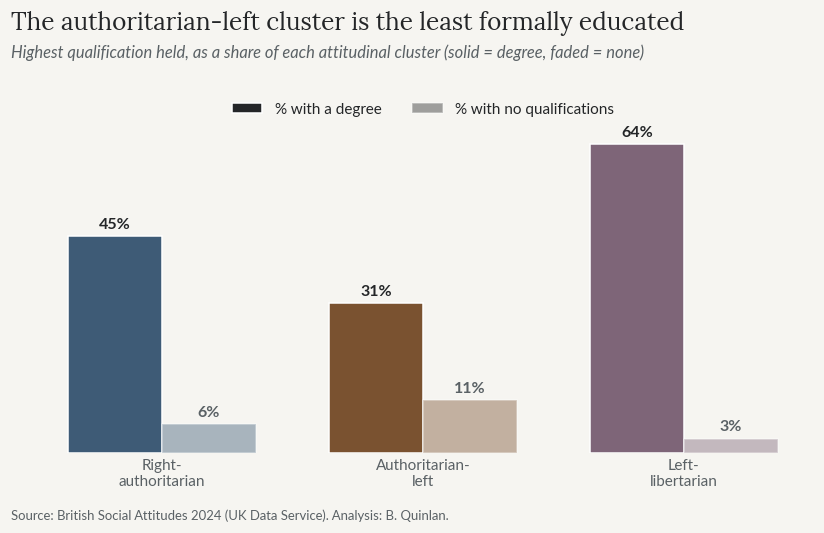

In [24]:
# --- 7b. Education (HEdQual2) as a direct test of the Brexitland successor thesis ---
import statsmodels.formula.api as smf

# Highest qualification: 1 = degree ... 6 = no quals; 8/9/906/-1 are non-substantive -> NaN
edu = analytic.copy()
edu['HEdQual2'] = edu['HEdQual2'].replace({8: np.nan, 9: np.nan, 906: np.nan, -1: np.nan})
edu['edu']     = edu['HEdQual2'].map({1: 5, 2: 4, 3: 3, 4: 2, 6: 1})           # higher = more qualified
edu['degree']  = np.where(edu['HEdQual2'].isna(), np.nan, (edu['HEdQual2'] == 1).astype(float))
edu['noquals'] = np.where(edu['HEdQual2'].isna(), np.nan, (edu['HEdQual2'] == 6).astype(float))
print(f"HEdQual2 valid for {edu['edu'].notna().sum()} of {len(edu)} respondents "
      f"({edu['edu'].notna().mean():.0%})—effectively full-sample.\n")

tbl = edu.groupby('cluster_km').agg(
        n=('edu', 'size'),
        pct_degree=('degree', lambda s: round(100*s.mean())),
        pct_no_quals=('noquals', lambda s: round(100*s.mean())),
        mean_qual_1to5=('edu', lambda s: round(s.mean(), 2)))
print("Highest qualification by cluster (whole analytic sample; 0=right-auth, 1=auth-left, 2=left-lib):")
print(tbl.to_string())

rf = edu[edu['Vote'] == 8].groupby('cluster_km').agg(
        reform_n=('edu', 'size'),
        pct_degree=('degree', lambda s: round(100*s.mean())),
        pct_no_quals=('noquals', lambda s: round(100*s.mean())))
print("\nAmong Reform voters:")
print(rf.to_string())

# (1) Brexitland's core claim: authoritarian (0/1) vs left-libertarian (2), controlling class + income
s2 = edu.dropna(subset=['edu', 'RClassGP', 'HHincome']).copy()
s2['auth'] = s2['cluster_km'].isin([0, 1]).astype(int)
m2 = smf.logit('auth ~ edu + C(RClassGP) + HHincome', data=s2).fit(disp=0)
print(f"\n(1) P(authoritarian cluster vs left-libertarian) ~ education + class + income   (n={len(s2)})")
print(f"    education OR = {np.exp(m2.params['edu']):.2f} per step up the qualification ladder "
      f"(z={m2.params['edu']/m2.bse['edu']:.2f}, p={m2.pvalues['edu']:.3f})")

# (2) Within the authoritarian half: does education separate auth-left (1) from right-auth (0)?
s1 = edu[edu['cluster_km'].isin([0, 1])].dropna(subset=['edu', 'RClassGP', 'HHincome']).copy()
s1['y'] = (s1['cluster_km'] == 1).astype(int)
m1 = smf.logit('y ~ edu + C(RClassGP) + HHincome', data=s1).fit(disp=0)
raw = smf.logit('y ~ edu', data=s1).fit(disp=0)
print(f"\n(2) P(authoritarian-LEFT | in the authoritarian half) ~ education + class + income   (n={len(s1)})")
print(f"    education OR = {np.exp(m1.params['edu']):.2f} per step (z={m1.params['edu']/m1.bse['edu']:.2f}, "
      f"p={m1.pvalues['edu']:.3f});  raw, no controls: OR = {np.exp(raw.params['edu']):.2f}")

# Figure: qualification profile by cluster
names = {0: 'Right-\nauthoritarian', 1: 'Authoritarian-\nleft', 2: 'Left-\nlibertarian'}
_order=[0,1,2]; _names=['Right-\nauthoritarian','Authoritarian-\nleft','Left-\nlibertarian']
_deg=[tbl.loc[_c,'pct_degree'] for _c in _order]; _noq=[tbl.loc[_c,'pct_no_quals'] for _c in _order]
fig,ax=plt.subplots(figsize=(7.8,5.0)); fig.subplots_adjust(left=0.06,right=0.97,top=0.80,bottom=0.15)
for _s in ('top','right','left','bottom'): ax.spines[_s].set_visible(False)
_x=np.arange(3); _w=0.36
for _i,_c in enumerate(_order):
    ax.bar(_x[_i]-_w/2,_deg[_i],_w,color=CLUSTER[_c]); ax.bar(_x[_i]+_w/2,_noq[_i],_w,color=CLUSTER[_c],alpha=0.42)
    ax.text(_x[_i]-_w/2,_deg[_i]+1,f'{int(_deg[_i])}%',ha='center',va='bottom',fontsize=10.5,color=INK,fontweight='bold')
    ax.text(_x[_i]+_w/2,_noq[_i]+1,f'{int(_noq[_i])}%',ha='center',va='bottom',fontsize=10.5,color=MUTED,fontweight='bold')
ax.set_xticks(_x); ax.set_xticklabels(_names); ax.set_yticks([]); ax.grid(False); ax.tick_params(length=0); ax.set_ylim(0,max(_deg)+10)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=INK,label='% with a degree'),Patch(facecolor=INK,alpha=0.42,label='% with no qualifications')],
          loc='upper center',ncol=2,frameon=False,fontsize=10,bbox_to_anchor=(0.5,1.02))
titleblock(fig,"The authoritarian-left cluster is the least formally educated",
    "Highest qualification held, as a share of each attitudinal cluster (solid = degree, faded = none)")
savefig('fig11_education-by-cluster.png'); plt.show()



The gradient runs exactly as the successor thesis predicts. The left-libertarian cluster is the
most credentialled (64% hold a degree), the conventional right-authoritarian less so (45%), and the
authoritarian-left cluster the least of all—just 31% with a degree and 11% with no qualifications
at all. On Brexitland's own terms the claim holds cleanly: even adjusting for social class and
household income, each step up the qualification ladder lowers the odds of sitting in an
authoritarian cluster rather than the libertarian one (OR 0.64, p < 0.001). Education is doing work
that economic position alone does not.

The sharper result is the second. Within the authoritarian half, education still separates the two
groups after the same adjustment: each qualification step lowers the odds of being in the
authoritarian-*left* cluster rather than the conventional-right one (OR 0.89, z = −3.3, p = 0.001),
and among Reform's own voters the raw gap is starker still—13% of the cross-pressured cluster hold
a degree against 29% of the conventional-right one. So Cluster 1 is not only economically insecure
and welfare-reliant; it is *educationally* marginal too, and because that gap survives adjustment
for class and income, it is consistent with education operating as Brexitland describes—a marker
of value socialisation—rather than as a stand-in for economic disadvantage. This is the fullest
statement of the left-behind profile the data will support: the cross-pressured group is
low-income-exposed, benefit-reliant and low-qualification at once, and the qualification signal is
not reducible to the other two. The claim remains associational—this is a cross-section, and
"net of class and income" is not the same as "independent of all economic circumstance"—but it is
a direct test of the successor thesis against the project's own clusters, and the thesis passes it.

### 7c. Naming the economic cross-pressure: welfare chauvinism

The economic profile of Cluster 1 has a specific shape worth naming, because it is not the generic
"economically left" position it first appears to be. The cluster **decouples** two attitudes that
the other two clusters keep welded together. It is pro-redistribution (`Redistrb` 2.18, close to the
left-libertarian cluster's 1.88) yet welfare-sceptical (`Welfare2` 3.14, close to the
right-authoritarian cluster's 3.32)—it favours taking income from the better-off without being
sympathetic to welfare claimants, and it is only lukewarm on higher public spending. Cavaillé and
Trump (2015) describe exactly this dissociation: redistribution understood as *taking from the rich*
draws on different motives from redistribution understood as *giving to the poor*, and the two can
diverge within the same voter. Cluster 1 endorses the first and resists the second.

Set that beside the cluster's other features—a majority reliant on benefits, and immigration
attitudes nearly as hostile as the conventional right's (on the split-ballot immigration items—small n,
so read as suggestive—around four-fifths of the cluster rate immigration bad for the economy)—and the position has a more precise name still. Support for
redistribution to an implied in-group, held alongside hostility to an out-group's claims on the same
welfare state, is the signature of what political scientists call **welfare chauvinism**—a term this project adopts from that scholarly literature, in its descriptive sense and not as a pejorative. Andersen and Bjørklund (1990)
coined watching Scandinavian Progress-party voters who "support redistribution but disagree that
immigrants should receive benefits," and it has since become central to explaining radical-right
support (Careja and Harris, 2022). One honest limit: BSA 2024 carries no direct "benefits for
natives only" item, so this is an interpretation of an attitude bundle—pro-redistribution,
welfare-sceptical, anti-immigration, benefit-reliant, and (from Section 7b) low-qualification—rather
than a measurement of chauvinist preference itself. But that bundle is precisely the one the concept
was built to describe.

Read this way the cross-pressure is sharper and less paradoxical than "a left-wing electorate inside
a right-wing party." Cluster 1 is not left-wing tout court; it is welfare-chauvinist, its redistributive
instinct real but bounded by who it judges deserving, in tension with Reform's tax-cutting platform on
the economic axis while fully aligned with the party on immigration and social order. That is the exact
location of the tension the whole project set out to find.

## 8. Geographic Triangulation

This section sets the regional distribution of BSA cluster membership (Section 4) against Reform's vote share in the 2025 local elections (House of Commons Library, *2025 Local Elections Handbook and Dataset*), and then against regional deprivation. It is offered as a cross-check on the attitudinal story, and three limits should be read before the table, not after it.

The first is coverage. The 2025 local elections were county and unitary contests in 23 English authorities only, mapping to 8 of the 12 BSA `GOR` regions. London, Scotland, Wales and Northern Ireland held no 2025 elections and drop out of this comparison—not because Reform is absent there, but because there is no 2025 local result to set against the survey.

The second is candidate coverage within those contests, which cuts in a specific and, for once, favourable direction. Reform contested very nearly the full slate nationally in 2025, so its own regional vote shares are not inflated by selective candidacy (the concern that would ordinarily attach to a rising party's first big local outing). Where a coverage gap existed in 2025 it was Labour's, concentrated in parts of the South West—one of this project's *lowest* Cluster-1 regions—so if anything it understates, rather than manufactures, the alignment the table shows. A more general caveat does apply to every party at once: these are multi-member wards, so `total_votes` scales with slate size, and the shares should be read as regional aggregates rather than exact per-elector rates.

The third is the ecological-inference gap, and it is the one this project is otherwise at pains to avoid. The core clustering is individual-level, which is its defence against the aggregate form of the left-behind critique; this section, by contrast, is deliberately aggregate—regional cluster shares against regional vote shares—so any alignment is suggestive at best. It cannot show that the same individuals drive both patterns, and the two electorates (a nationally representative survey; a lower-turnout, off-cycle local election of a different type) are not the same electorate. This is a descriptive cross-check, treated as one throughout, and it is not asked to carry the individual-level claim.

A third dataset is added at this point: the English Indices of Deprivation 2019 (IMD2019, MHCLG), upper-tier local authority summaries, aggregated to the same eight regions (higher = more deprived). If Cluster 1 concentrates in objectively more deprived regions, that extends the "left-behind" reading from attitude into measured circumstance; if the two diverge, that is worth seeing too.

In [25]:
import openpyxl

# --- 1. Reform UK vote share by authority, 2025 local elections ---
wb = openpyxl.load_workbook('data/LEH-2025-results-HoC.xlsx', read_only=True)
ws = wb['Candidates result']

rows = []
for r in ws.iter_rows(min_row=3, values_only=True):
    if r[0] is None:
        continue
    rows.append({'authority': r[3], 'party': r[6], 'votes': r[10]})

cand = pd.DataFrame(rows)
cand['votes'] = pd.to_numeric(cand['votes'], errors='coerce')

authority_totals = cand.groupby('authority')['votes'].sum()
reform_votes = cand[cand['party'] == 'Reform UK'].groupby('authority')['votes'].sum()
reform_share = (reform_votes / authority_totals).fillna(0)

# --- 2. Map English county/unitary authorities (2025 locals) to BSA GOR regions ---
authority_to_gor = {
    'Buckinghamshire': 'South East', 'Cambridgeshire': 'East of England', 'Cornwall': 'South West',
    'Derbyshire': 'East Midlands', 'Devon': 'South West', 'Doncaster': 'Yorkshire and The Humber',
    'Durham': 'North East', 'Gloucestershire': 'South West', 'Hertfordshire': 'East of England',
    'Kent': 'South East', 'Lancashire': 'North West', 'Leicestershire': 'East Midlands',
    'Lincolnshire': 'East Midlands', 'North Northamptonshire': 'East Midlands',
    'Northumberland': 'North East', 'Nottinghamshire': 'East Midlands', 'Oxfordshire': 'South East',
    'Shropshire': 'West Midlands', 'Staffordshire': 'West Midlands', 'Warwickshire': 'West Midlands',
    'West Northamptonshire': 'East Midlands', 'Wiltshire': 'South West', 'Worcestershire': 'West Midlands',
}

locals_2025 = pd.DataFrame({
    'authority': authority_totals.index,
    'total_votes': authority_totals.values,
    'reform_votes': reform_votes.reindex(authority_totals.index).fillna(0).values,
})
locals_2025['GOR'] = locals_2025['authority'].map(authority_to_gor)

regional_2025 = locals_2025.groupby('GOR')[['total_votes', 'reform_votes']].sum()
regional_2025['reform_share_2025_locals'] = regional_2025['reform_votes'] / regional_2025['total_votes']

# --- 3. BSA: Cluster 1 share and Reform vote share by GOR region ---
gor_labels = {1: 'East Midlands', 2: 'East of England', 3: 'London', 4: 'North East',
               5: 'North West', 6: 'Northern Ireland', 7: 'Scotland', 8: 'South East',
               9: 'South West', 10: 'Wales', 11: 'West Midlands', 12: 'Yorkshire and The Humber'}

analytic['GOR_label'] = analytic['GOR'].map(gor_labels)

cluster1_share = analytic.groupby('GOR_label')['cluster_km'].apply(lambda s: (s == 1).mean())
reform_share_bsa = analytic.groupby('GOR_label')['Vote'].apply(lambda s: (s == 8).mean())
region_n = analytic.groupby('GOR_label').size()

bsa_regional = pd.DataFrame({
    'n_respondents': region_n,
    'pct_cluster1': (cluster1_share * 100).round(1),
    'reform_vote_share_2024GE_BSA': (reform_share_bsa * 100).round(1),
})

# --- 4. Combine, restricted to the 8 regions with 2025 local elections ---
combined = bsa_regional.join(
    (regional_2025['reform_share_2025_locals'] * 100).round(1).rename('reform_vote_share_2025_locals'),
    how='inner'
)
combined = combined.sort_values('pct_cluster1', ascending=False)
combined

# --- 5. English Indices of Deprivation 2019 (IMD), aggregated to the same GOR regions ---
imd_wb = openpyxl.load_workbook('data/IoD2019_LA_upper_tier.xlsx', read_only=True)
imd_ws = imd_wb['IMD']
imd_rows = list(imd_ws.iter_rows(min_row=2, values_only=True))
imd_df = pd.DataFrame(imd_rows, columns=[
    'la_code', 'la_name', 'imd_avg_rank', 'imd_rank_of_avg_rank', 'imd_avg_score',
    'imd_rank_of_avg_score', 'imd_prop_most_deprived_10pct', 'imd_rank_prop_most_deprived',
    'imd_extent', 'imd_rank_extent', 'imd_local_concentration', 'imd_rank_local_concentration'
])[['la_name', 'imd_avg_score']]

# IMD2019 uses pre-2021 LA boundaries: 'County Durham' (not 'Durham'), and a single
# 'Northamptonshire' (the 2021 split into North/West Northamptonshire post-dates IMD2019)
imd_name_map = {
    'Durham': 'County Durham',
    'North Northamptonshire': 'Northamptonshire',
    'West Northamptonshire': 'Northamptonshire',
}
imd_lookup = imd_df.set_index('la_name')['imd_avg_score']
locals_2025['imd_la_name'] = locals_2025['authority'].map(lambda a: imd_name_map.get(a, a))
locals_2025['imd_avg_score'] = locals_2025['imd_la_name'].map(imd_lookup)

# Population-weighting the LA -> region step (by electorate), so a small county and a
# big metro authority don't count equally—and it sidesteps a district -> county mapping
ward_ws = openpyxl.load_workbook('data/LEH-2025-results-HoC.xlsx', read_only=True)['Ward results']
electorate = {}
for wr in ward_ws.iter_rows(min_row=3, values_only=True):
    auth = wr[3]                                  # 'Upper tier authority'
    if auth is None:
        continue
    try:
        electorate[auth] = electorate.get(auth, 0.0) + float(wr[8] or 0)   # 'Electorate'
    except (TypeError, ValueError):
        pass
locals_2025['electorate'] = locals_2025['authority'].map(electorate)

def _weighted_imd(g):
    return np.average(g['imd_avg_score'], weights=g['electorate'])

regional_imd     = locals_2025.groupby('GOR')[['imd_avg_score', 'electorate']].apply(_weighted_imd)
regional_imd     = regional_imd.rename('imd_avg_score_region')
regional_imd_unw = locals_2025.groupby('GOR')['imd_avg_score'].mean()

combined = combined.join(regional_imd.round(2), how='left')
combined = combined[['n_respondents', 'pct_cluster1', 'reform_vote_share_2024GE_BSA',
                      'reform_vote_share_2025_locals', 'imd_avg_score_region']]

# Robustness: electorate-weighting should not change the substantive regional ordering.
same_rank = bool((regional_imd.rank(ascending=False).sort_index().values ==
                  regional_imd_unw.rank(ascending=False).sort_index().values).all())
print(f"Electorate-weighted vs unweighted regional IMD: identical rank order = {same_rank}")
combined

Electorate-weighted vs unweighted regional IMD: identical rank order = True


,n_respondents,pct_cluster1,reform_vote_share_2024GE_BSA,reform_vote_share_2025_locals,imd_avg_score_region
North East,154,39.6,5.8,37.6,24.94
West Midlands,338,36.7,11.8,34.0,16.80
North West,488,36.1,10.0,35.7,23.44
Yorkshire and The Humber,342,36.0,8.5,40.6,30.29
East of England,392,30.9,6.1,23.6,13.14
East Midlands,253,28.9,9.1,35.7,17.81
South East,531,25.6,10.0,27.7,15.68
South West,394,24.4,9.9,26.2,17.01


### Reading the regional comparison

The table is restricted to the eight regions with 2025 local results and sets three quantities side by side per region: `pct_cluster1` (the share of that region's BSA respondents in Cluster 1), Reform's general-election vote share within the BSA sample there, and Reform's share across all candidates in the region's 2025 contests.

The columns broadly move together. The regions heaviest in Cluster 1—North East (39.6%), West Midlands (36.7%), North West (36.1%) and Yorkshire and The Humber (36.0%)—are also among Reform's strongest in the 2025 locals (37.6%, 34.0%, 35.7% and 40.6% respectively). The two regions lightest in Cluster 1, the South East (25.6%) and South West (24.4%), sit near the bottom on the local vote too. That is consistent with Cluster 1 marking a real, geographically patterned constituency that votes Reform both nationally and locally—but no more than consistent. With only eight regions and two very different electoral contexts, a formal correlation would carry almost no statistical weight, and none is reported, since quoting one would imply a precision the comparison does not have.

Deprivation tells a similar story with one honest exception. `imd_avg_score_region` is the IMD average score of each region's upper-tier authorities, electorate-weighted (from the same House of Commons Library handbook, which sidesteps aggregation bias without a separate population dataset; the weighting barely moves the figures and leaves the ranking unchanged). The most Cluster-1-heavy regions—North East, Yorkshire and The Humber, and North West—are also among the most deprived (24.9, 30.3, 23.4), which pushes the "left-behind" reading past attitude into material circumstance. The West Midlands is the exception, high on Cluster 1 but only moderately deprived (16.8), and is left visible rather than smoothed away. As with the vote comparison, this is a descriptive n=8 cross-check: a regional average is not the deprivation any individual respondent actually lives in.

---
## 9. Supervised Comparison: Predicting Reform UK Voters

Sections 2–8 work unsupervised: cluster the whole sample on attitudes, then ask where Reform voters land. This section poses the complementary supervised question. Using the same five attitude features (`Libauth`, `Welfare2`, `Redistrb`, `TaxSpend`, `leftrigh`), how well can a classifier predict `Vote==8` directly, and do the features it leans on agree with the PCA loadings of Section 3?

A decision tree is used, applied to a markedly imbalanced target: Reform voters are 329 of 3,966, about 8.3% of the analytic sample. That imbalance is handled head-on rather than papered over. A classifier that simply predicted "not Reform" for everyone would score 92% accuracy and be useless. So `class_weight='balanced'` penalises the tree for missing the minority class, and precision, recall and ROC-AUC, not accuracy, are the metrics reported. The tree's depth and minimum leaf size are not fixed by hand but selected by five-fold cross-validated ROC-AUC on the training set, so the model is tuned rather than assumed.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              roc_curve, roc_auc_score)

# Stratified train/test split, preserving the ~8% Reform rate
y = (analytic['Vote'] == 8).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Train: n={len(y_train)}, Reform={y_train.sum()} ({y_train.mean():.1%})")
print(f"Test:  n={len(y_test)}, Reform={y_test.sum()} ({y_test.mean():.1%})")

Train: n=2776, Reform=230 (8.3%)
Test:  n=1190, Reform=99 (8.3%)


In [27]:
# Tuning depth and leaf size by 5-fold CV on ROC-AUC, rather than fixing them by hand
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {'max_depth': [2, 3, 4, 5, 6, 7, 8], 'min_samples_leaf': [1, 5, 10, 20]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid, scoring='roc_auc', cv=cv, n_jobs=-1,
).fit(X_train, y_train)

best_params = grid.best_params_
print(f"Best parameters (5-fold CV, ROC-AUC): {best_params}")
print(f"Best cross-validated ROC-AUC: {grid.best_score_:.3f}")

# Validation curve over depth (at the selected leaf size) for the write-up
ms_leaf = best_params['min_samples_leaf']
depth_scores = {}
for d in param_grid['max_depth']:
    depth_scores[d] = GridSearchCV(
        DecisionTreeClassifier(max_depth=d, min_samples_leaf=ms_leaf,
                               class_weight='balanced', random_state=42),
        {}, scoring='roc_auc', cv=cv,
    ).fit(X_train, y_train).best_score_
print(f"CV ROC-AUC by max_depth (min_samples_leaf={ms_leaf}): "
      + ", ".join(f"{d}:{s:.3f}" for d, s in depth_scores.items()))

Best parameters (5-fold CV, ROC-AUC): {'max_depth': 3, 'min_samples_leaf': 5}
Best cross-validated ROC-AUC: 0.720
CV ROC-AUC by max_depth (min_samples_leaf=5): 2:0.707, 3:0.720, 4:0.714, 5:0.690, 6:0.679, 7:0.650, 8:0.628


              precision    recall  f1-score   support

  Not Reform       0.96      0.62      0.76      1091
   Reform UK       0.15      0.73      0.25        99

    accuracy                           0.63      1190
   macro avg       0.56      0.68      0.50      1190
weighted avg       0.89      0.63      0.71      1190

ROC-AUC: 0.733


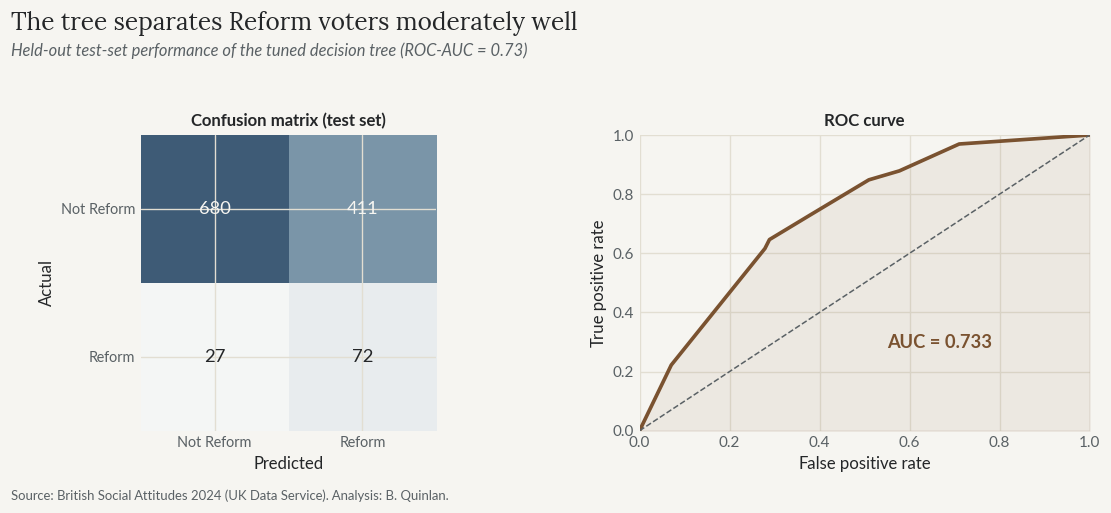

In [28]:
# Fitting the tuned tree, then scoring on the held-out test set
tree = DecisionTreeClassifier(class_weight='balanced', random_state=42, **best_params)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
y_proba = tree.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Reform', 'Reform UK']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
from sklearn.metrics import roc_curve, confusion_matrix
_auc=roc_auc_score(y_test,y_proba); _cm=confusion_matrix(y_test,y_pred)
_seq=LinearSegmentedColormap.from_list('seq',SEQUENTIAL)
fig,axes=plt.subplots(1,2,figsize=(10.6,4.8)); fig.subplots_adjust(left=0.08,right=0.96,top=0.72,bottom=0.16,wspace=0.28)
ax=axes[0]; im=ax.imshow(_cm,cmap=_seq); _mx=_cm.max()
ax.set_xticks([0,1]); ax.set_yticks([0,1]); ax.set_xticklabels(['Not Reform','Reform'],fontsize=9.5); ax.set_yticklabels(['Not Reform','Reform'],fontsize=9.5)
for _i in range(2):
    for _j in range(2):
        ax.text(_j,_i,f'{_cm[_i,_j]:,}',ha='center',va='center',fontsize=12,color=(CANVAS if _cm[_i,_j]>_mx*0.55 else INK))
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Confusion matrix (test set)',fontsize=11,color=INK,fontweight='bold',pad=6)
for _s in ax.spines.values(): _s.set_visible(False)
ax.tick_params(length=0)
ax2=axes[1]
for _s in ('top','right','left','bottom'): ax2.spines[_s].set_visible(False)
ax2.grid(True,color=GRID); ax2.tick_params(length=0)
_fpr,_tpr,_=roc_curve(y_test,y_proba)
ax2.plot(_fpr,_tpr,color=OCHRE,lw=2.4); ax2.plot([0,1],[0,1],'--',color=MUTED,lw=1); ax2.fill_between(_fpr,_tpr,color=OCHRE,alpha=0.08)
ax2.text(0.55,0.28,f'AUC = {_auc:.3f}',color=OCHRE,fontsize=12,fontweight='bold')
ax2.set_xlabel('False positive rate'); ax2.set_ylabel('True positive rate'); ax2.set_title('ROC curve',fontsize=11,color=INK,fontweight='bold',pad=6)
ax2.set_xlim(0,1); ax2.set_ylim(0,1)
titleblock(fig,"The tree separates Reform voters moderately well",
    f"Held-out test-set performance of the tuned decision tree (ROC-AUC = {_auc:.2f})")
savefig('fig08_decision-tree-confusion-roc.png'); plt.show()



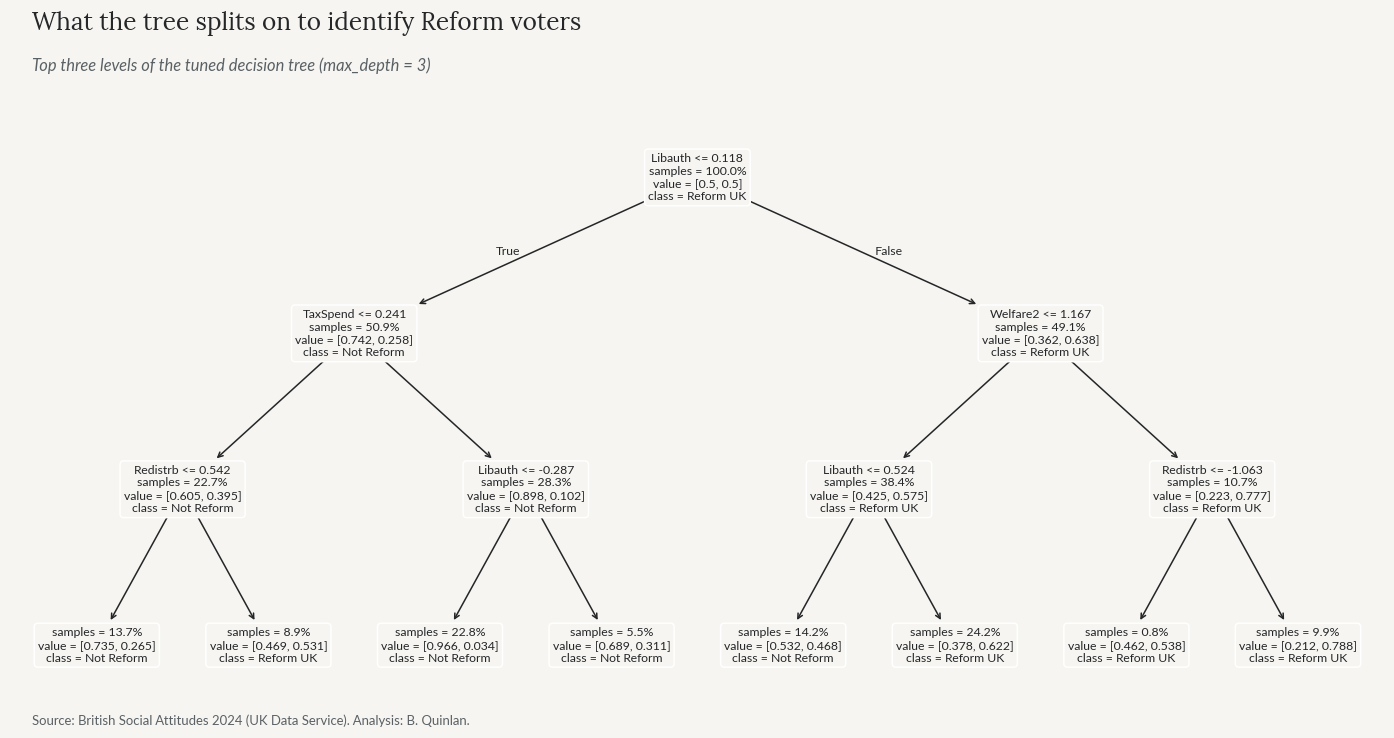

In [29]:
# Drawing the top of the tree in the report style
from sklearn.tree import plot_tree
fig,ax=plt.subplots(figsize=(13,7)); fig.subplots_adjust(left=0.02,right=0.98,top=0.84,bottom=0.03)
plot_tree(tree,feature_names=pca_features,class_names=['Not Reform','Reform UK'],filled=False,rounded=True,
          max_depth=3,fontsize=8,ax=ax,impurity=False,proportion=True)
fig.patch.set_facecolor(CANVAS)
titleblock(fig,"What the tree splits on to identify Reform voters",
    f"Top three levels of the tuned decision tree (max_depth = {best_params.get('max_depth','?')})")
savefig('fig09_decision-tree-diagram.png'); plt.show()


In [30]:
# Compare decision-tree feature importances against the PCA loadings (Section 3)
importance = pd.DataFrame({
    'tree_importance': tree.feature_importances_,
    'abs_PC1_loading': loadings['PC1'].abs(),
    'abs_PC2_loading': loadings['PC2'].abs(),
}, index=pca_features).sort_values('tree_importance', ascending=False)
importance.round(3)

,tree_importance,abs_PC1_loading,abs_PC2_loading
Libauth,0.688,0.373,0.583
TaxSpend,0.140,0.390,0.256
Welfare2,0.102,0.504,0.299
Redistrb,0.070,0.504,0.426
leftrigh,0.000,0.447,0.569


In [31]:
# Where do the tree's predicted Reform voters fall in the k-means cluster solution (Section 4)?
# X is a numpy array (from StandardScaler), so recover test-set rows via the y_test index
test_idx = y_test.index
pred_df = pd.DataFrame({
    'cluster_km': analytic.loc[test_idx, 'cluster_km'].values,
    'actual_reform': y_test.values,
    'predicted_reform': y_pred,
})

print('Cluster distribution of TRUE Reform voters (test set):')
print(pred_df[pred_df['actual_reform'] == 1]['cluster_km'].value_counts(normalize=True).sort_index().round(3))
print()
print('Cluster distribution of PREDICTED Reform voters (test set):')
print(pred_df[pred_df['predicted_reform'] == 1]['cluster_km'].value_counts(normalize=True).sort_index().round(3))

Cluster distribution of TRUE Reform voters (test set):
cluster_km
0    0.495
1    0.465
2    0.040
Name: proportion, dtype: float64

Cluster distribution of PREDICTED Reform voters (test set):
cluster_km
0    0.563
1    0.422
2    0.014
Name: proportion, dtype: float64


### Interpreting the supervised comparison

The tree confirms from the supervised side what the clustering found unsupervised, and the way it fails is itself part of the result.

The cross-validation settles the model's shape rather than leaving it to assumption. The search selects `max_depth=3` with `min_samples_leaf=5`, and the CV ROC-AUC is essentially flat across depths 2–4 (0.707, 0.720, 0.714) before falling away as deeper trees overfit, so a shallow tree is the principled choice, not merely a convenient one. The tuned tree reaches a cross-validated ROC-AUC of 0.720 and a test-set ROC-AUC of 0.733.

Class imbalance is real and shapes the metrics. With Reform at 8.3% of the sample, `class_weight='balanced'` trades precision for a substantial gain in minority-class recall (recall 0.73, ROC-AUC 0.733). The headline accuracy of 0.63 is the misleading number the balancing exists to discount, and it is reported only to be set aside.

On feature importance, the supervised and unsupervised pictures converge cleanly. `Libauth` dominates the tree's splits (importance 0.69) and is also the heaviest loader on PC2 (0.58), the cross-pressure axis. The tree never saw the PCA structure and the PCA never saw `Vote`, so their agreement on which attitude carries the most signal is genuine convergent evidence rather than circularity.

The most interesting result is where the tree goes wrong. True Reform voters in the test set split roughly 50 / 47 / 4 across the three clusters, but the voters the tree *predicts* as Reform split 56 / 42 / 1—pulled toward Cluster 0 and away from Cluster 1. The tree is better at recognising the "conventional" Reform profile than the "left-behind" one. That is not a failure to explain away but a finding in its own right: Cluster 1's Reform voters are harder to tell apart from non-Reform voters on attitudes alone, precisely because their authoritarian-left position is shared with many people who do not vote Reform. A cross-pressured group should be hard to classify, and this one is—the effect is more modest than a first, uncorrected pass suggested, but it points the same way. The supervised model reinforces the cross-pressure narrative rather than competing with it. This section does not claim a deployment exercise: the tree is a second algorithm turned on the same data from the opposite direction, used to interrogate the unsupervised result, not to build a predictor anyone would ship.

---
## 10. Longitudinal Check: Is Cluster 1 a 2024-Specific Phenomenon?

Every section to this point rests on a single cross-section, BSA 2024. This one asks a genuinely different question. Did the "authoritarian-left" profile of Cluster 1 already exist a decade earlier, at the radical right's previous high-water mark, with UKIP at its 2014 peak, when it took 27.5% of the May 2014 European Parliament vote?

The method is projection, not re-fitting. Re-running PCA and K-means from scratch on 2014 data would produce a different 2D space and different clusters, and the comparison would be meaningless. Instead, the already-fitted `scaler`, `pca` and `kmeans` objects from Sections 2–4 are applied to the 2014 respondents through `.transform()` and `.predict()`. The question this poses is precise: had a 2014 respondent answered the 2024 survey, where would the 2024 model place them? It tests directly whether the cluster structure is a stable feature of the underlying attitude space or an artefact of one year's sample.

The data is BSA 2014 (UKDA SN 7809), using the same five attitude scales (`libauth`, `welfare2`, `redistrb`, `TaxSpend`, `leftrigh`), which have kept consistent wording and 1–5 scoring since the late 1980s and 2000s per the NatCen user guide. Party identification (`PartyIDN`) identifies UKIP identifiers (code 7, n=268 in the full sample and 210 in the analytic subset after listwise deletion) as the closest 2014 analogue to 2024 Reform voters.

Three caveats bound what follows. First, party *identification* in 2014 and general-election *vote* in 2024 are different question types, identification being the looser and more durable attachment, so UKIP identifiers and Reform voters are analogues rather than equivalents. Second, a decade of upheaval, the Brexit referendum above all, sits between the snapshots, so any difference may be real attitude change rather than a difference of party. Third, this is one additional cross-section, not a time series. It establishes whether the pattern existed at one earlier point, not how it travelled between them.

In [32]:
# Load BSA 2014 (UKDA SN 7809) and recode the same 5 attitude items
bsa14 = pd.read_csv('data/bsa14_final.tab', sep='\t', low_memory=False)

# libauth / leftrigh / welfare2: stored as strings; ' ' = no self-completion, '9' = missing
for col in ['libauth', 'leftrigh', 'welfare2']:
    bsa14[col] = pd.to_numeric(bsa14[col].replace(['9', ' '], np.nan), errors='coerce')

# redistrb: -1 = no self-completion, 9 = missing
bsa14['redistrb'] = bsa14['redistrb'].replace([-1, 9], np.nan)

# TaxSpend: code 4 = 'None' (frame rejection, per codebook) plus 8/9 = DK/refused -> NaN,
# for consistency with the 2024 recoding in Section 1.3
bsa14['TaxSpend'] = bsa14['TaxSpend'].replace([4, 8, 9], np.nan)

features_2014 = ['libauth', 'welfare2', 'redistrb', 'TaxSpend', 'leftrigh']
analytic_2014 = bsa14.dropna(subset=features_2014).copy()

print(f"BSA 2014: n={len(bsa14)}, analytic sample after dropping missing on 5 features: "
      f"n={len(analytic_2014)} ({len(analytic_2014)/len(bsa14):.1%})")
print(f"UKIP identifiers (PartyIDN==7) in analytic sample: {(analytic_2014['PartyIDN']==7).sum()}")

BSA 2014: n=2878, analytic sample after dropping missing on 5 features: n=2227 (77.4%)
UKIP identifiers (PartyIDN==7) in analytic sample: 210


In [33]:
# Project 2014 respondents into the 2024-fitted PCA/K-means space.
# Column order must match pca_features = ['Libauth','Welfare2','Redistrb','TaxSpend','leftrigh']
# reattach the 2024 feature names so the fitted scaler recognises the columns
X_2014 = pd.DataFrame(analytic_2014[features_2014].to_numpy(), columns=pca_features)
X_2014_scaled = scaler.transform(X_2014)          # SAME scaler fitted on 2024 data—not refit
X_pca_2014 = pca.transform(X_2014_scaled)         # SAME PCA components
# SAME K-means centroids, then the SAME deterministic relabelling as Section 4
cluster_2014 = np.array([cluster_remap[l] for l in kmeans.predict(X_pca_2014)])
analytic_2014['cluster_km_2024model'] = cluster_2014

print("2014 respondents projected into 2024 cluster space—overall distribution:")
print((analytic_2014['cluster_km_2024model'].value_counts(normalize=True)
       .sort_index().round(3)))

2014 respondents projected into 2024 cluster space—overall distribution:
cluster_km_2024model
0    0.438
1    0.410
2    0.151
Name: proportion, dtype: float64


In [34]:
# Compare: where do 2014 UKIP identifiers fall, vs. where 2024 Reform voters fell (Section 4)?
ukip_2014 = analytic_2014[analytic_2014['PartyIDN'] == 7]
reform_2024 = analytic[analytic['Vote'] == 8]

comparison = pd.DataFrame({
    '2014: whole sample (proj.)': analytic_2014['cluster_km_2024model'].value_counts(normalize=True).sort_index(),
    '2014: UKIP identifiers (proj.)': ukip_2014['cluster_km_2024model'].value_counts(normalize=True).sort_index(),
    '2024: whole sample': analytic['cluster_km'].value_counts(normalize=True).sort_index(),
    '2024: Reform UK voters': reform_2024['cluster_km'].value_counts(normalize=True).sort_index(),
}).round(3)
comparison.index.name = 'cluster'
print(f"n (2014 UKIP identifiers, analytic) = {len(ukip_2014)}")
print(f"n (2024 Reform UK voters, analytic) = {len(reform_2024)}")

# Cluster-1 share with 95% Wilson CIs, and a two-proportion test on the gap
from scipy.stats import norm
k1, n1 = int((ukip_2014['cluster_km_2024model'] == 1).sum()), len(ukip_2014)
k2, n2 = int((reform_2024['cluster_km'] == 1).sum()), len(reform_2024)
lo1, hi1 = wilson_ci(k1, n1); lo2, hi2 = wilson_ci(k2, n2)
print(f"\nCluster 1 share, 2014 UKIP identifiers:  {100*k1/n1:.1f}% (95% CI [{lo1:.1f}, {hi1:.1f}], n={n1})")
print(f"Cluster 1 share, 2024 Reform UK voters:  {100*k2/n2:.1f}% (95% CI [{lo2:.1f}, {hi2:.1f}], n={n2})")
pooled = (k1 + k2) / (n1 + n2)
zstat = (k1/n1 - k2/n2) / np.sqrt(pooled*(1-pooled)*(1/n1 + 1/n2))
print(f"Two-proportion z-test: z={zstat:.2f}, p={2*(1-norm.cdf(abs(zstat))):.4f} "
      f"(unweighted; see Limitations on survey design)")

comparison


# --- Over-representation, risk/odds ratios, and a difference-in-differences test ---
# The raw two-proportion test compares Cluster-1 SHARE between the two party bases. But the
# whole-population Cluster-1 share also fell over the decade, so part of that gap is the
# attitudinal space contracting under everyone rather than the coalition specifically moving.
# We therefore express each base's over-representation RELATIVE TO ITS OWN YEAR'S population,
# and test whether that relative position changed—a difference-in-differences on the
# log-odds scale, i.e. the interaction term of a logistic regression. Both Reform-relevant
# clusters are held to the SAME test, so the strengthening and weakening readings are treated
# even-handedly.
import statsmodels.formula.api as smf

rows=[]
for c in [0, 1]:
    u  = (ukip_2014['cluster_km_2024model']==c).mean()
    r  = (reform_2024['cluster_km']==c).mean()
    p14= (analytic_2014['cluster_km_2024model']==c).mean()
    p24= (analytic['cluster_km']==c).mean()
    rows.append(dict(cluster=c, UKIP14=round(100*u,1), pop14=round(100*p14,1), RR14=round(u/p14,2),
                     Reform24=round(100*r,1), pop24=round(100*p24,1), RR24=round(r/p24,2)))
overrep=pd.DataFrame(rows).set_index('cluster')
print("Over-representation within the radical-right base, relative to each year's population")
print("(RR = base share / population share; >1 = over-represented):")
print(overrep.to_string())

stack=pd.concat([
    pd.DataFrame({'incluster':analytic_2014['cluster_km_2024model'].values,
                  'party':(analytic_2014['PartyIDN']==7).astype(int).values,'year':0}),
    pd.DataFrame({'incluster':analytic['cluster_km'].values,
                  'party':(analytic['Vote']==8).astype(int).values,'year':1}),
], ignore_index=True)
print("\nDifference-in-differences (logistic interaction party x year), by cluster:")
for c in [0, 1]:
    d=stack.assign(inc=(stack['incluster']==c).astype(int))
    m=smf.logit('inc ~ party * year', data=d).fit(disp=0)
    b=m.params['party:year']; z=b/m.bse['party:year']; p=m.pvalues['party:year']
    print(f"  Cluster {c}: OR(2014)={np.exp(m.params['party']):.2f}x -> OR(2024)="
          f"{np.exp(m.params['party']+b):.2f}x | change in log-OR={b:+.2f} (z={z:.2f}, p={p:.3f})")


n (2014 UKIP identifiers, analytic) = 210
n (2024 Reform UK voters, analytic) = 329

Cluster 1 share, 2014 UKIP identifiers:  59.0% (95% CI [52.3, 65.5], n=210)
Cluster 1 share, 2024 Reform UK voters:  41.0% (95% CI [35.9, 46.4], n=329)
Two-proportion z-test: z=4.08, p=0.0000 (unweighted; see Limitations on survey design)
Over-representation within the radical-right base, relative to each year's population
(RR = base share / population share; >1 = over-represented):
         UKIP14  pop14  RR14  Reform24  pop24  RR24
cluster                                            
0          36.7   43.8  0.84      55.0   40.6  1.36
1          59.0   41.0  1.44      41.0   30.7  1.34

Difference-in-differences (logistic interaction party x year), by cluster:
  Cluster 0: OR(2014)=0.72x -> OR(2024)=1.89x | change in log-OR=+0.96 (z=5.09, p=0.000)
  Cluster 1: OR(2014)=2.24x -> OR(2024)=1.64x | change in log-OR=-0.31 (z=-1.65, p=0.100)


### Reading the longitudinal comparison

The projection answers the question cleanly, and the way to read it correctly takes two steps rather than one.

The first, headline comparison is the two radical-right columns. Where 2024 Reform voters fall 41.0% into Cluster 1 (95% CI [35.9, 46.4], n=329), 2014 UKIP identifiers fall 59.0% into it (95% CI [52.3, 65.5], n=210). The intervals do not overlap, and a two-proportion test puts the gap well beyond sampling noise (z = 4.08, p < 0.001). Read on its own, this says the authoritarian-left profile was not merely present in the radical right's base a decade ago—it was the *majority* profile of UKIP's identifiers at their electoral peak. That is strong support for the Ford and Goodwin framing as describing a durable, decade-spanning feature of this part of the electorate rather than a one-off reading of 2024.

But the raw share is the wrong quantity for the more specific question of whether Reform's *coalition* has moved, because the whole population's Cluster-1 share also fell over the decade—from 41.0% in 2014 to 30.7% in 2024, projected into the same space. Part of the 59%→41% drop is that the attitudinal room for an authoritarian-left position contracted under everyone, not that the party shed that bloc. The honest way to separate the two is to measure each base's over-representation *relative to its own year's population*, and to test whether that relative position changed—a difference-in-differences on the log-odds scale (the interaction term of a logistic regression), applied even-handedly to both Reform-relevant clusters.

Done that way, the two clusters tell different stories. Cluster 1's over-representation is essentially unchanged: UKIP identifiers were 1.44× as likely as the 2014 population to be in it, Reform voters 1.34× as likely as the 2024 population—still markedly over-represented in both years, and the difference-in-differences is not distinguishable from zero (change in log-odds −0.31, z = −1.65, p = 0.10). Cluster 0, the conventional right-authoritarian, is where the real movement is: UKIP identifiers were *under*-represented in it (0.84×, odds ratio 0.72), whereas Reform voters are *over*-represented (1.36×, odds ratio 1.89), a flip that clears significance comfortably (change in log-odds +0.96, z = 5.09, p < 0.001).

So the defensible reading of the decade is not that Reform "broadened away from" the left-behind core, but that it *broadened by adding a conventional-right layer on top of it*. The left-behind bloc remains disproportionately present in the base; what changed is the arrival of right-authoritarian voters who were not part of UKIP's 2014 coalition. That is exactly the distinction the *Brexitland* literature draws between an electorate changing its mind (conversion) and the coalition itself being recomposed (composition), and the pattern here is more consistent with the second. One caveat bounds this firmly: BSA 2014 and 2024 are independent cross-sections, not a panel, so this establishes that the *aggregate* profile shifted, not that any individual converted. Adjudicating conversion against composition at the individual level would need panel data such as the BES—the very evidence Evans and Mellon bring to the original debate—and is beyond what a repeated cross-section can settle. What this section does establish is that the authoritarian-left profile is durable and long-predates Reform, and that the coalition's rightward broadening since 2014 is real and statistically clear.

## Conclusion

The question this project set out to answer was whether Reform UK's electoral coalition is attitudinally unified or whether it harbours a substantial cross-pressured subgroup. The evidence is clear, and it is the second. Clustered on attitudes alone, with no sight of vote choice, Reform's 2024 voters divide almost evenly between two distinct profiles: a conventional right-authoritarian half (Cluster 0, 55.0%) and an authoritarian-left half (Cluster 1, 41.0%) that is pro-redistribution, left-leaning, and disproportionately reliant on state benefits. Profiled closely (Sections 7–7c), that second half is sharper than "economically left": it fits what the literature calls welfare chauvinism—redistributive but welfare-sceptical, anti-immigration, benefit-reliant and, net of class and income, distinctly lower-qualification—which places the cross-pressure precisely, between its redistributive economics and Reform's fiscal platform rather than as a wholesale mismatch of a left electorate and a right party. The single category "Reform voter" conceals a coalition that clustering pulls cleanly into two.

What gives that finding its weight is not any single model but the way independent methods converge on it, and—just as importantly—the way the one method that *disagrees* was run down rather than dropped. Principal component analysis isolates the authoritarian-left axis (PC2) as a real dimension of the attitude space. Ward hierarchical clustering, on the corrected data, agrees with K-means substantially (ARI 0.75), and the residual disagreement is confined to the soft border between the two Reform clusters rather than touching the left-libertarian cluster. A supervised decision tree, turned on the same data from the opposite direction, leans on the same dominant attitude (`Libauth`) and struggles to classify Cluster 1's Reform voters—exactly what a genuinely cross-pressured group should do to a classifier. And a battery of robustness checks shows the split is invariant to the choices that matter: dropping the weakest variable, clustering on the full five-dimensional space, adding a component, or resampling the respondents all leave it essentially unchanged, with Cluster-1 membership stable across bootstraps at probability 0.98.

The autoencoders are where the analysis is most openly a record of enquiry, and they earn their place precisely by *not* delivering a tidy confirmation. A first, `tanh`-bottleneck network appeared to recover the clusters at high agreement (ARI 0.70); interrogating that number exposed a geometric confound, and a second, linear-bottleneck network built to remove it reconstructs the data slightly better than PCA yet clusters quite differently (ARI ≈ 0.39), reorganising the space around a single variable. The honest synthesis of the two is a decomposition of uncertainty rather than a robustness trophy: the linear subspace is adequate for *reconstruction* whichever network is used, but the exact three-way *partition* is sensitive to how the embedding is drawn. Set against the bootstrap and the robustness checks, this locates the project's real uncertainty: it is not sampling (the split is near-immune to that), nor variable choice or dimensionality (it survives both), but a wholesale change of embedding geometry—and even that redrawing is traceable to the discreteness of a single variable the split is shown not to need. The existence of the authoritarian-left bloc is what every other method agrees on; the autoencoder is the honest dissent, and one the rest of the evidence explains rather than one that unseats the result.

The longitudinal check supplies the final piece, and it too rewards being read carefully rather than quickly. Projected into the 2024-defined cluster space, 2014 UKIP identifiers fall into Cluster 1 even more heavily than 2024 Reform voters do (59.0% against 41.0%). But the population's own authoritarian-left share shrank over the decade, so the sharper question—did Reform's coalition move?—is answered by over-representation relative to each year's population, tested even-handedly. On that test Cluster 1's over-representation is durable and statistically unchanged (1.44× → 1.34×; difference-in-differences z = −1.65, p = 0.10), while Cluster 0 flips decisively from under- to over-represented (0.84× → 1.36×; z = 5.09, p < 0.001). The reading is not that Reform abandoned the left-behind, but that it broadened by adding a conventional-right layer on top of a left-behind core that was there all along—a compositional shift in *Brexitland*'s sense, though one this repeated cross-section can describe rather than prove at the individual level, since separating conversion from composition would require panel data. And where the coalition's trajectory points toward *Brexitland*, a direct test of that book's central mechanism passes: the cross-pressured cluster is markedly the least credentialled of the three (31% hold a degree, against 45% and 64%), and the gap holds net of social class and household income—consistent with education operating as a marker of value socialisation rather than a mere proxy for economic position (Section 7b).

Read as a whole, the project takes a question that has been approached descriptively—who supports Reform—and answers a sharper version with machine learning: not who they are, but whether they are one electorate or two, whether the tension inside the second half is real, robust and lasting, and where the analysis's own uncertainty actually sits. On this evidence the coalition is two electorates; the cross-pressure in the second is real and long-standing; and the residual doubt is a matter of where a soft boundary falls, honestly bounded rather than papered over. None of this is a causal account, and the subgroup figures are descriptive rather than inferential. What the analysis establishes is structure and its persistence—across linear and nonlinear embeddings, unsupervised and supervised methods, and a decade of data—not mechanism.

### Limitations & Future Work

The Reform subsample is modest (n=336 in the full 2024 sample; 329 after listwise deletion), so the Section 7 subgroup figures are descriptive and exploratory rather than inferential, and are reported with their n throughout. The split-ballot design confines the LGB and immigration items to roughly a quarter of the sample, which is why they profile clusters rather than define them; the British Election Study 2024 was checked as a larger-sample alternative (n=3,089; Reform n=221) but its identity-by-attitude overlap is still small (n≈4–9) and uses a different attitude measure, so it was not substituted in.

Three limitations are worth stating in their own right because a critical reader will reach for them. First, the "welfare-reliant" character of Cluster 1 is compositional (benefit receipt), not attitudinal: the welfarism *scale* barely separates the two Reform clusters, and the report is careful not to claim otherwise. Second, the geographic triangulation in Section 8 is aggregate by construction and is deliberately not asked to carry the individual-level claim; it is a descriptive cross-check subject to the ecological-inference gap the core analysis is otherwise designed to avoid. Third, the longitudinal projection rests on two independent cross-sections, so it can show that the authoritarian-left profile is durable and that the coalition broadened, but it cannot separate voters converting from the coalition being recomposed—that distinction needs panel data.

On the modelling itself, the choice of k=3 over the silhouette-optimal k=2 was substantive and is reported transparently, with the cost quantified; reassuringly, the two-cluster story the title states is exactly what k=2 recovers, with k=3 merely peeling off the small left-libertarian fringe. The partition's uncertainty is characterised directly in Section 5b rather than asserted: it is robust to variable choice, dimensionality and resampling, and the one axis along which it does move—embedding geometry, surfaced by the linear-bottleneck autoencoder—is confined to the soft boundary between Clusters 0 and 1. Finally, the clustering itself is unweighted, which is standard—fitting survey weights inside an unsupervised pipeline is non-standard. The reported percentages and their Wilson intervals therefore describe the analytic sample rather than the design-corrected population, and BSA's stratified, clustered design means those intervals are a floor on the true uncertainty. As a check on how much this matters, reweighting the final Reform cross-tab to BSA's published final weight leaves the split materially unchanged (52 / 44 / 4 against the unweighted 55 / 41 / 4), so the headline is not an artefact of the unweighted design. A genuine multi-wave panel treatment of the conversion-versus-composition question remains the natural extension beyond this scope.

## References

Andersen, J.G. and Bjørklund, T. (1990) 'Structural Changes and New Cleavages: the Progress Parties in Denmark and Norway', *Acta Sociologica*, 33(3), pp. 195–217.

British Election Study Team (2025) *British Election Study, 2024: Random Probability Sample* [data collection]. UK Data Service. SN: 9502.

Careja, R. and Harris, E. (2022) 'Thirty years of welfare chauvinism research: Findings and challenges', *Journal of European Social Policy*, 32(2), pp. 212–224.

Cavaillé, C. and Trump, K.-S. (2015) 'The Two Facets of Social Policy Preferences', *The Journal of Politics*, 77(1), pp. 146–160.

Evans, G. and Mellon, J. (2016) 'Working Class Votes and Conservative Losses: Solving the UKIP Puzzle', *Parliamentary Affairs*, 69(2), pp. 464–479.

Ford, R. and Goodwin, M.J. (2014) *Revolt on the Right: Explaining Support for the Radical Right in Britain*. Abingdon: Routledge.

Hillygus, D.S. and Shields, T.G. (2008) *The Persuadable Voter: Wedge Issues in Presidential Campaigns*. Princeton: Princeton University Press.

House of Commons Library (2025) *2025 Local Elections Handbook and Dataset* (C. Rallings, M. Thrasher and H. Bunting, Elections Centre, University of Exeter). London: House of Commons Library. Available at: https://commonslibrary.parliament.uk/2025-local-elections-handbook-and-dataset/ (Accessed: 17 June 2026).

Lazarsfeld, P.F., Berelson, B. and Gaudet, H. (1944) *The People's Choice: How the Voter Makes Up His Mind in a Presidential Campaign*. New York: Columbia University Press.

Ministry of Housing, Communities & Local Government (2019) *English Indices of Deprivation 2019*. London: Ministry of Housing, Communities & Local Government. Available at: https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019 (Published 26 September 2019).

NatCen Social Research (2016) *British Social Attitudes Survey, 2014* [data collection]. UK Data Service. SN: 7809, http://doi.org/10.5255/UKDA-SN-7809-2

NatCen Social Research (2025) *British Social Attitudes Survey, 2024* [data collection]. UK Data Service. SN: 9478, http://doi.org/10.5255/UKDA-SN-9478-1

NatCen Social Research (2026) *British Social Attitudes 43: Who Supports Reform?* London: NatCen Social Research.

Norris, P. and Inglehart, R. (2019) *Cultural Backlash: Trump, Brexit, and Authoritarian Populism*. Cambridge: Cambridge University Press.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. and Duchesnay, É. (2011) 'Scikit-learn: Machine Learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.

Reform UK (2024) *Our Contract with You*. London: Reform UK. Published 17 June 2024.

Sobolewska, M. and Ford, R. (2020) *Brexitland: Identity, Diversity and the Reshaping of British Politics*. Cambridge: Cambridge University Press.